# Problem Statement - INN Hotels

### **Problem Statements**

**Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.


**Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help shortlist candidates with higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.

* Recommend a suitable profile for the applicants for whom the visa should be * certified or denied based on the drivers that significantly influence the case status.



**Data Description**

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* **case_id:** ID of each visa application
* **continent:** Information of continent the employee
* **education_of_employee:** Information of education of the employee
* **has_job_experience:** Does the employee have any job experience? Y= Yes; N = No
* **requires_job_training:** Does the employee require any job training? Y = Yes; N = No
* **no_of_employees:** Number of employees in the employer's company
* **yr_of_estab:** Year in which the employer's company was established
* **region_of_employment:** Information of foreign worker's intended region of employment in the US.
* **prevailing_wage:** Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* **unit_of_wage:** Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* **full_time_position:** Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* **case_status:** Flag indicating if the Visa was certified or denied

## **Importing the necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Library to split data
from sklearn.model_selection import train_test_split


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# read the data from the drive
file_path = r"/content/drive/MyDrive/EasyVisa.csv"
data = pd.read_csv(file_path)

## **Data Overview**

#### **Create a copy of the data**

In [ ]:
# let's create a copy of the data to avoid any changes to original data
df = data.copy()

#### **Displaying the first & last few rows of the dataset**

In [ ]:
# view the first 5 rows
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# view the last 5 rows
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### **Checking 10 random rows of the dataset**

In [ ]:
df.sample(n=10, random_state=1)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
17639,EZYV17640,Asia,Bachelor's,Y,N,567,1992,Midwest,26842.9100,Year,Y,Certified
23951,EZYV23952,Oceania,Bachelor's,N,N,619,1938,Midwest,66419.9800,Year,Y,Certified
8625,EZYV8626,Asia,Master's,N,N,2635,2005,South,887.2921,Hour,Y,Certified
20206,EZYV20207,Asia,Bachelor's,Y,Y,3184,1986,Northeast,49435.8000,Year,Y,Certified
7471,EZYV7472,Europe,Bachelor's,Y,N,4681,1928,West,49865.1900,Year,Y,Denied
3433,EZYV3434,Asia,Bachelor's,Y,N,222,1989,South,813.7261,Hour,Y,Certified
24440,EZYV24441,Europe,High School,N,Y,3278,1994,South,204948.3900,Year,Y,Denied
12104,EZYV12105,Asia,Master's,Y,N,1359,1997,West,202237.0400,Year,N,Certified
15656,EZYV15657,Asia,Bachelor's,N,N,2081,2003,West,111713.0200,Year,Y,Denied
23110,EZYV23111,North America,Bachelor's,Y,N,854,1998,Northeast,444.8257,Hour,Y,Denied


#### **Checking the shape of the dataset**

In [ ]:
# Checking how many rows and columns are present in the data
df.shape

(25480, 12)

##### Observations:
* There are `25480 rows` & `12 columns` in the given dataset.

#### **Checking the data types of the columns for the dataset**

In [ ]:
# inspecting the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
# group by data type
df.dtypes.value_counts()

,count
object,9
int64,2
float64,1


##### Observations:
* *`9 columns`* are of the `object` type columns and *`2 columns`* are of `numerical` type columns.
* The `prevailing_wage` column is continous in nature.
* All the columns have `25480 observations`, which means none of the columns has `null values`.

#### **Statistical summary of the dataset**

In [ ]:
# Checking the statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


##### Observations:

- The `no_of_employees` column has a wide range, including negative values, indicating the need for data cleaning (negative values in `no_of_employees` are unrealistic and should be addressed).  

- The company's `yr_of_estab` has a mean value of `1979.4`, with a standard deviation of `42.37`. The minimum year is `1800`, while the maximum year is `2016`.

- The `maximum`, `minimum`, and `mean` values for *`prevailing_wage`* are `$319,210`, `$2`, and `$74,455`, respectively.


#### **Cleaning negative values in the no_of_employees column by converting them to positive values**

In [ ]:
# Identify negative values in no_of_employees columns
negative_values = df[df['no_of_employees'] < 0]
negative_values.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.99,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.14,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.94,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.46,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.97,Hour,Y,Denied


In [ ]:
# Convert negative values into positive values by taking the absolute values
df['no_of_employees'] = df['no_of_employees'].abs()

In [ ]:
df.no_of_employees.describe()

,no_of_employees
count,25480.000000
mean,5667.089207
std,22877.917453
min,11.000000
25%,1022.000000
50%,2109.000000
75%,3504.000000
max,602069.000000


##### Observations:

- The minimum, maximum, and mean values in the `no_of_employees` column were `11 employees`, `602069 employees`, and approximately `5667 employees`, respectively.

#### **Checking for null values**

In [ ]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


##### Observations:

* As we can see, all the columns has `0 missing values`. It means, there are no missing values in the data.

#### **Checking for duplicate values**

In [ ]:
df.duplicated().sum()

0

##### Observations:
* There are *`no duplicate`* values in the data.

#### **Create New Column company_age**

In [ ]:
# Creating new column company_age (Mathematically, Current_year - yr_of_estab)
current_year = datetime.now().year
print(f"Current Year: {current_year}")
df['company_age'] = current_year - df['yr_of_estab']
df.head()

Current Year: 2025


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,18
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,23
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,17
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,128
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,20


## **Exploratory Data Analysis (EDA)**

### **Model Support Functions**

In [ ]:
# function to create both Histogram & Box-Plot

def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        # data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
        data=data, x=feature, ax=ax_box2, showmeans=True
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        # data[feature].mean(), color="green", linestyle="--"
        data[feature].mean(), linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        # data[feature].median(), color="black", linestyle="-"
        data[feature].median(), linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create Barplot

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top
    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="deep",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = int(p.get_height())  # count of each level of the category without decimals

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Return category counts as a DataFrame with Denied and Certified percentages and plot a stacked bar chart.

    Parameters:
    data: DataFrame
        The dataset to analyze.
    predictor: str
        The independent variable (x-axis).
    target: str
        The target variable (used for stacked bars).

    Returns:
    pd.DataFrame
        A DataFrame showing category counts with margins and percentage columns.
    """
    # Generate crosstab DataFrame and plot with counts
    crosstab_df = pd.crosstab(data[predictor], data[target])
    crosstab_df.plot(
        # kind="bar", stacked=True, figsize=(10, 6), alpha=0.8, color=["#1f77b4", "#ff7f0e"]
        kind="bar", stacked=True, figsize=(10, 6), alpha=0.8
    )

    # Add totals on top of bars
    for index, row in enumerate(crosstab_df.values):
        total = sum(row)
        plt.text(index, total + 0.02, str(total), ha="center", fontsize=10)

    # Add legend and labels
    plt.title(f"Stacked Bar Chart: {predictor} vs {target}")
    plt.ylabel("Count")
    plt.xlabel(predictor)
    plt.legend(title=target, loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()
    print()

    # Calculate totals and percentages
    crosstab_df["All"] = crosstab_df.sum(axis=1)
    if "Denied" in crosstab_df.columns:
        crosstab_df["Denied(%)"] = (
            (crosstab_df["Denied"] / crosstab_df["All"]) * 100
        ).round(2)
    if "Certified" in crosstab_df.columns:
        crosstab_df["Certified(%)"] = (
            (crosstab_df["Certified"] / crosstab_df["All"]) * 100
        ).round(2)

    return crosstab_df

In [ ]:
# function to plot distributions wrt target

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def line_plot_with_two_lines(df, index_col, columns_col, values_col='case_status'):
  """
  Creates a line plot to visualize the booking status trend across a specified index column.
  Automatically handles x-tick labels.

  Args:
      df: The input DataFrame.
      index_col: The name of the column to use as the index (x-axis).
      columns_col: The name of the column to use for creating separate lines (booking status).
      values_col: The name of the column to aggregate (count of bookings). Defaults to 'Booking_ID'.
  """
  # Create a pivot table to aggregate booking counts
  pivot_table = pd.pivot_table(
      df,
      values=values_col,
      index=index_col,
      columns=columns_col,
      aggfunc='count',
      fill_value=0
  )

  # Rename columns if 'case_status' is the columns_col
  if columns_col == 'case_status':
    pivot_table = pivot_table.rename(
        columns={'Denied': 'Denied', 'Certified': 'Certified'}
    )


  # Create the line plot using seaborn
  plt.figure(figsize=(12, 6))
  sns.lineplot(data=pivot_table)

  # Customize the plot
  plt.title(f'Case Status Trend Across {index_col.title()}')
  plt.xlabel(index_col.title())
  plt.ylabel('Number of Case Status')

  # Automatically set x-axis tick labels based on index column values
  plt.xticks(pivot_table.index, pivot_table.index)

  if columns_col == 'case_status':
      plt.legend(title='Case Status')
  else:
      plt.legend(title=columns_col.title())  # Use a generic legend title if columns_col is not 'case_status'

  plt.show()

### **Numerical & Categorical Columns**

In [ ]:
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
numerical_col

['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'company_age']

In [ ]:
categorical_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_col

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

### Univariate Analysis

#### Distribution of **`no_of_employees`** *(Numerical Column)*

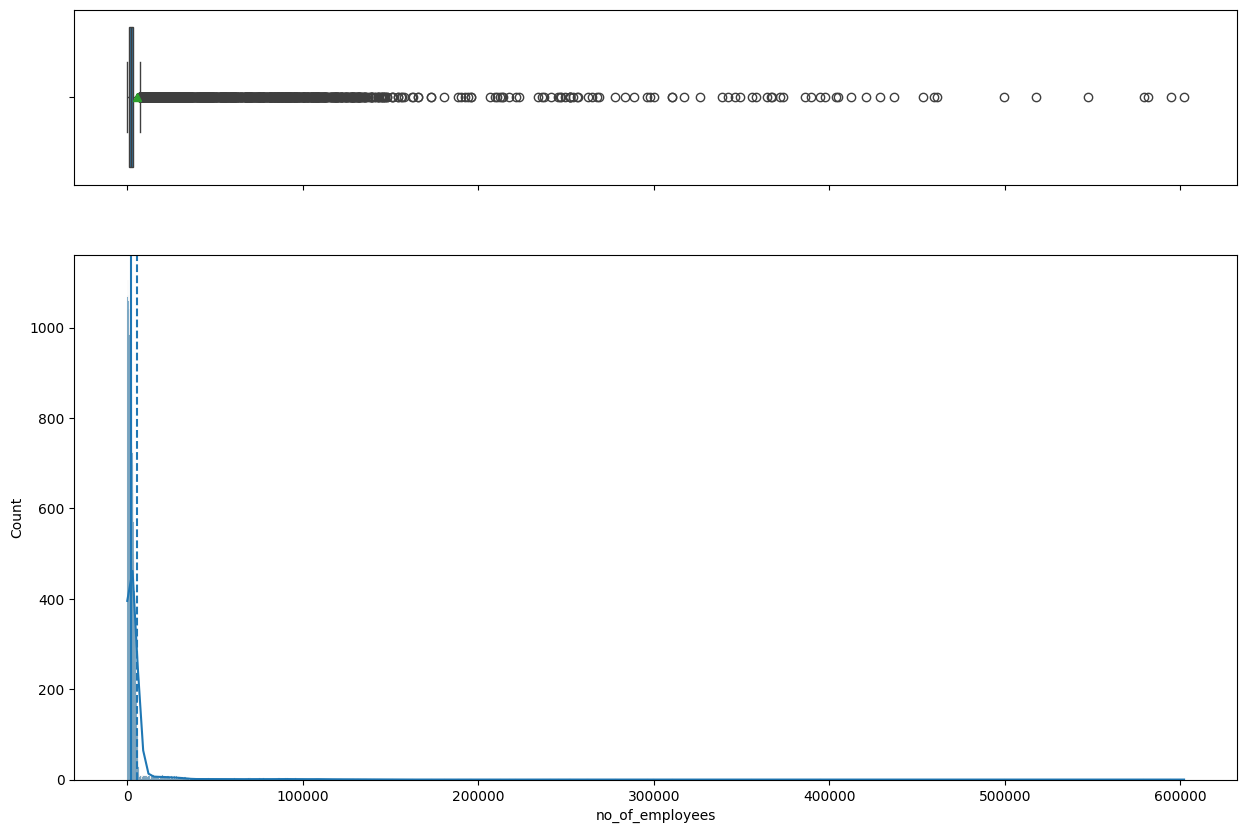

In [ ]:
histogram_boxplot(df, "no_of_employees", kde=True)

##### Observations:

* The `no_of_employees` variable has a `highly right-skewed` distribution with `numerous outliers`.

#### Distribution of **`yr_of_estab`** *(Numerical Column)*

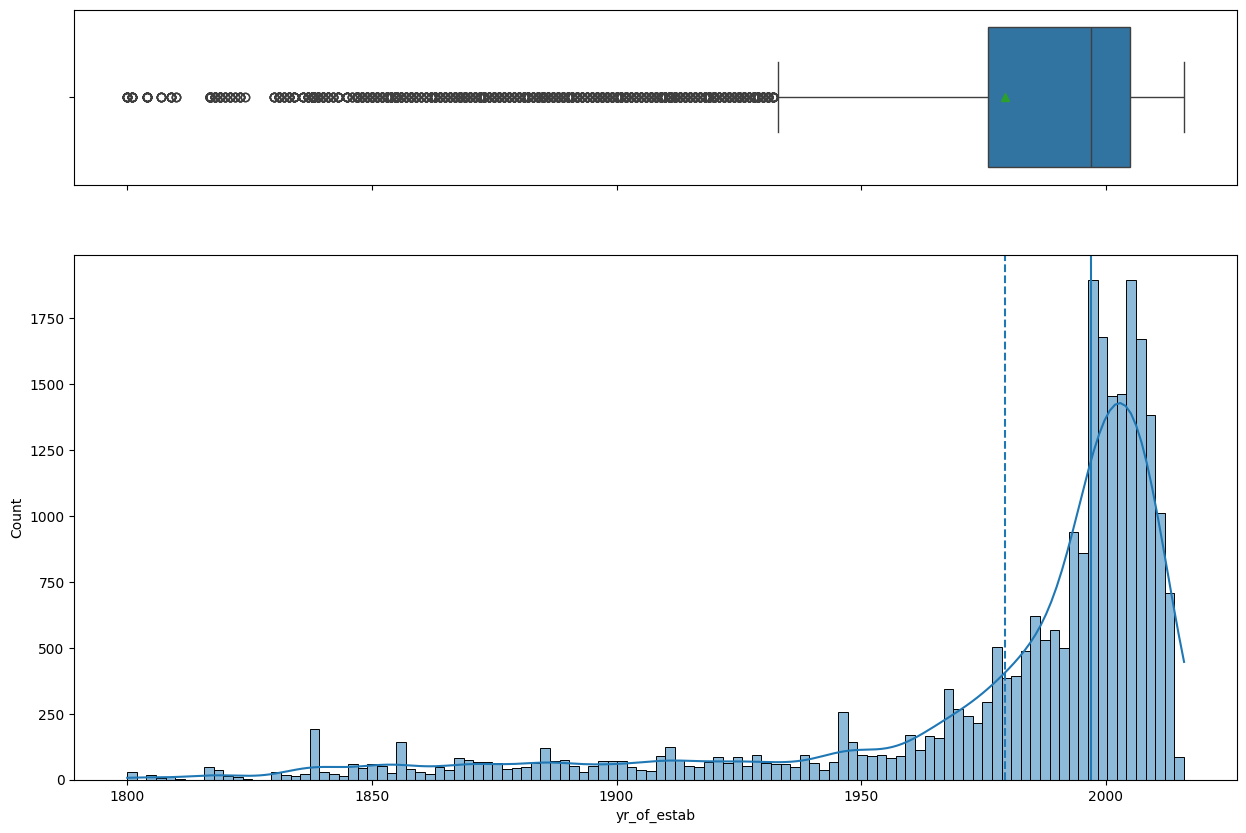

In [ ]:
histogram_boxplot(df, "yr_of_estab", kde=True)

##### Observations:

* The `yr_of_estab` variable has a left-skewed distribution with outliers.

* Most of the companies were establied after 1997.

#### Distribution of **`company_age`** *(Numerical Column)*

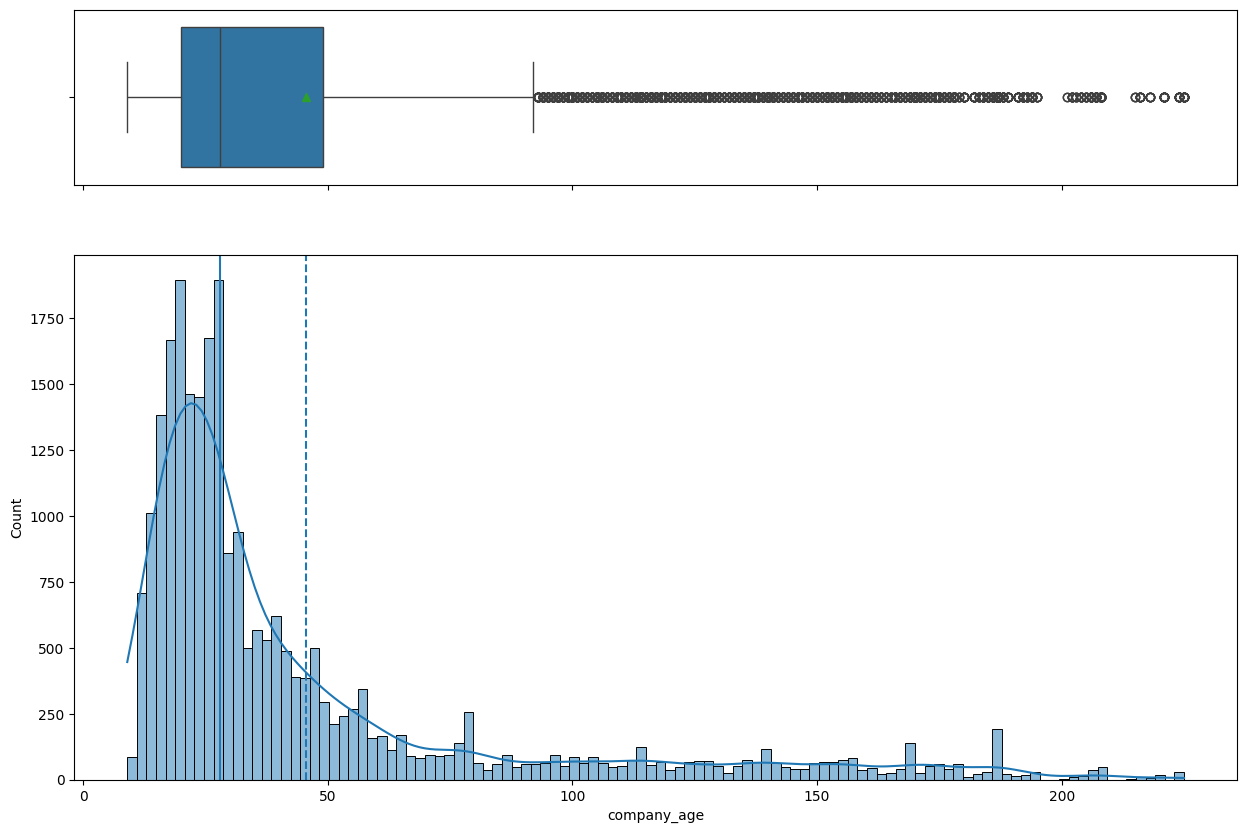

In [ ]:
histogram_boxplot(df, "company_age", kde=True)

In [ ]:
df['company_age'].describe()

,company_age
count,25480.000000
mean,45.590071
std,42.366929
min,9.000000
25%,20.000000
50%,28.000000
75%,49.000000
max,225.000000


##### Observations:

* The `company_age` variable has a right-skewed distribution with outliers.

* The `maximum`, `minimum` and `mean` ages of the companies are `225 years`, `9 years` and `45.5 years` respectively.

#### Distribution of **`prevailing_wage`** *(Numerical Column)*

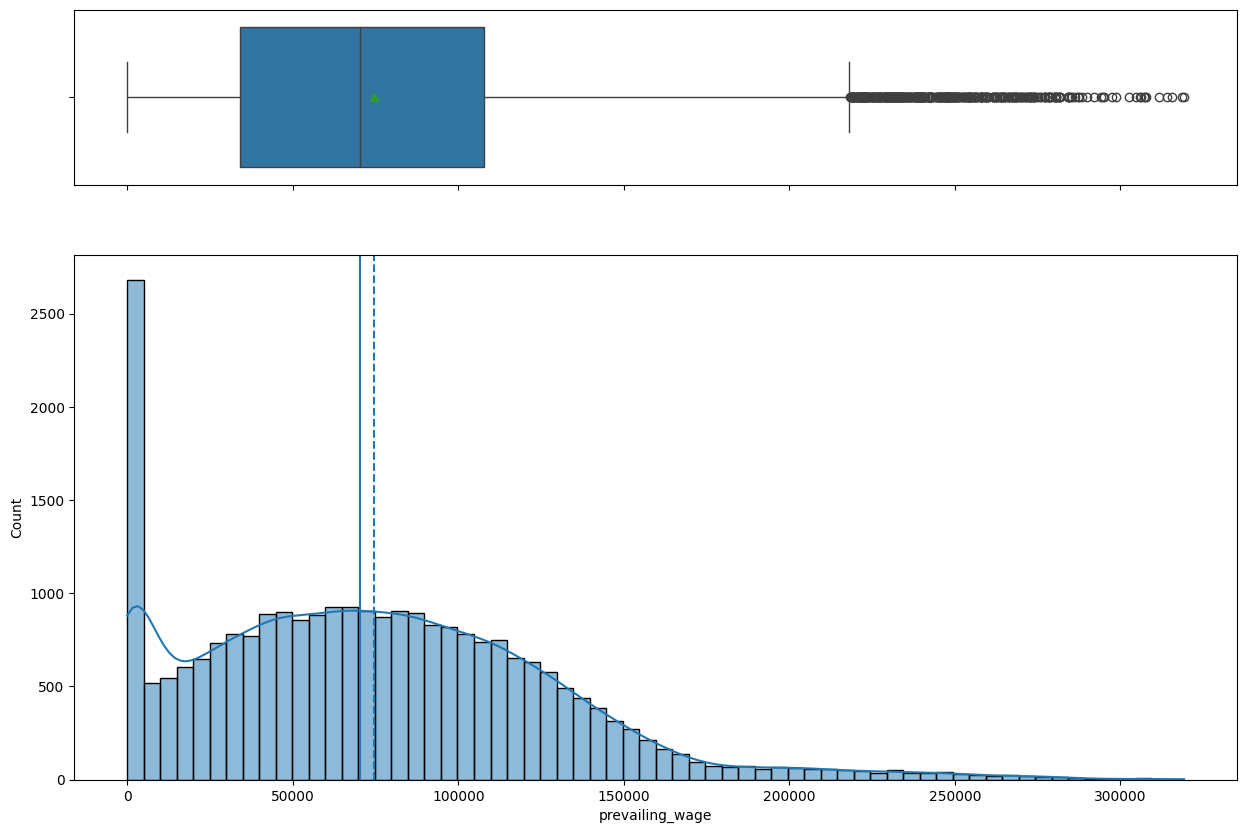

In [ ]:
histogram_boxplot(df, "prevailing_wage", kde=True)

In [ ]:
df.prevailing_wage.describe()

,prevailing_wage
count,25480.000000
mean,74455.814592
std,52815.942327
min,2.136700
25%,34015.480000
50%,70308.210000
75%,107735.512500
max,319210.270000


##### Observations:

* The `maximum`, `minimum` and `mean` *`prevailing_wage`* are `319210 `, `2 ` and `74455 ` respectively.

#### Distribution of **`continent`** *(Categorical Column)*

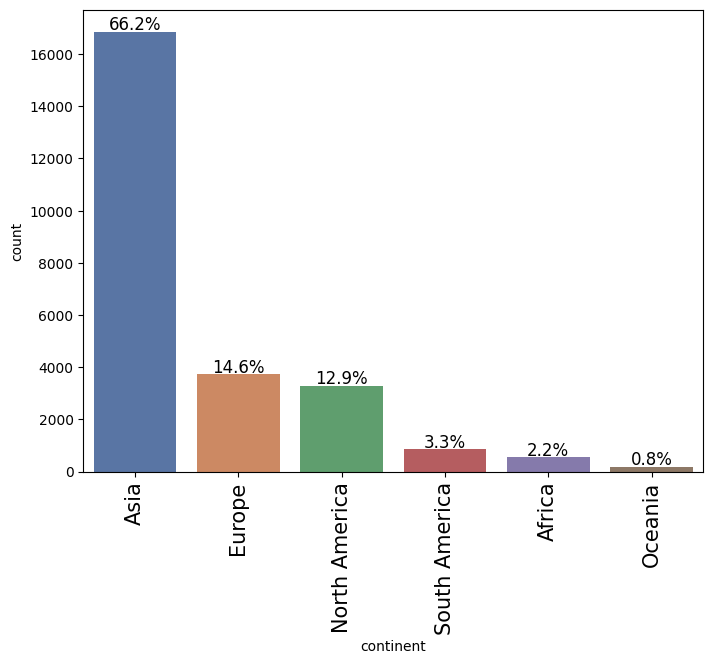

In [ ]:
labeled_barplot(df, 'continent', perc=True);

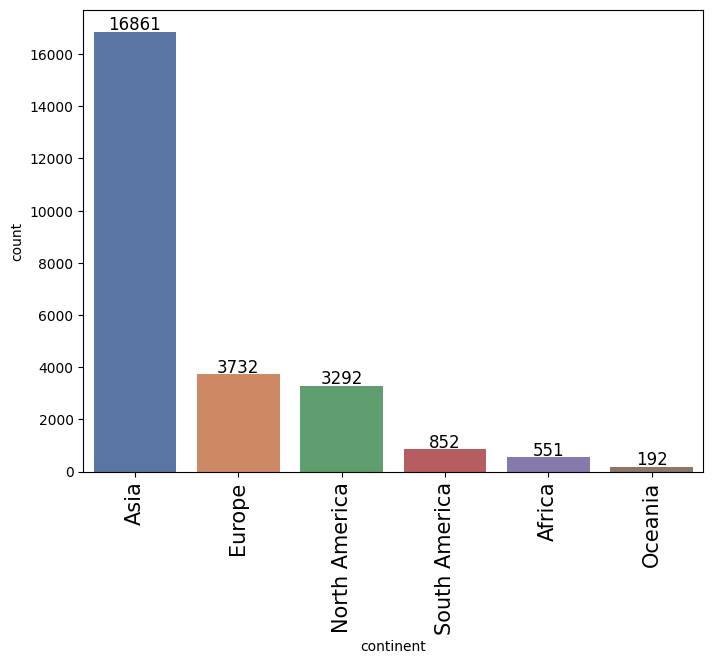

In [ ]:
labeled_barplot(df, 'continent');

##### Observations:

* `16861 employees` (`approximately 66.2%`) come from **Asian continent**, followed by Europe (*`3732 employees, 14.6%`*), Nort America (*`3292 employees, 12.9%`* of the total employess) and several other regions.

#### Distribution of **`education_of_employee`** *(Categorical Column)*

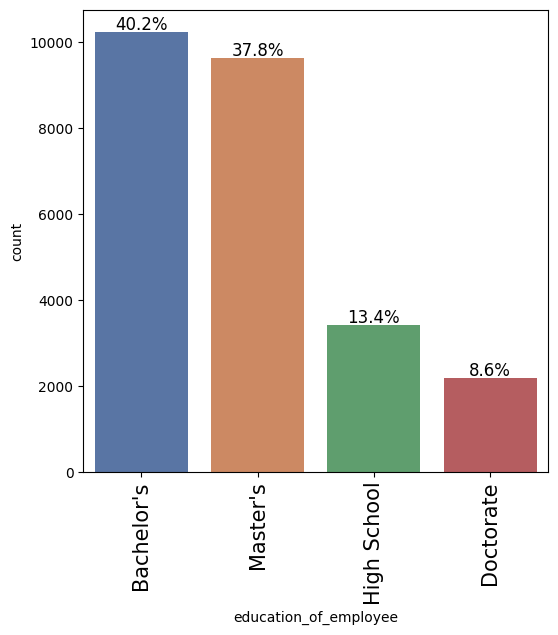

In [ ]:
labeled_barplot(df, 'education_of_employee', perc=True);

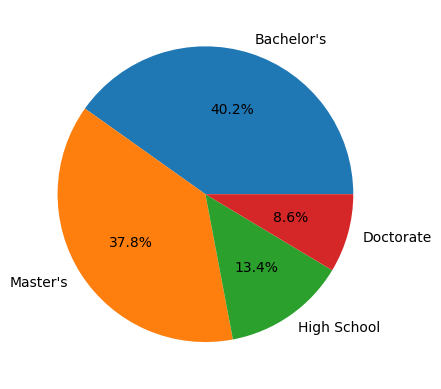

In [ ]:
plt.pie(df['education_of_employee'].value_counts(), labels=["Bachelor's", "Master's", "High School", "Doctorate"], autopct='%1.1f%%');

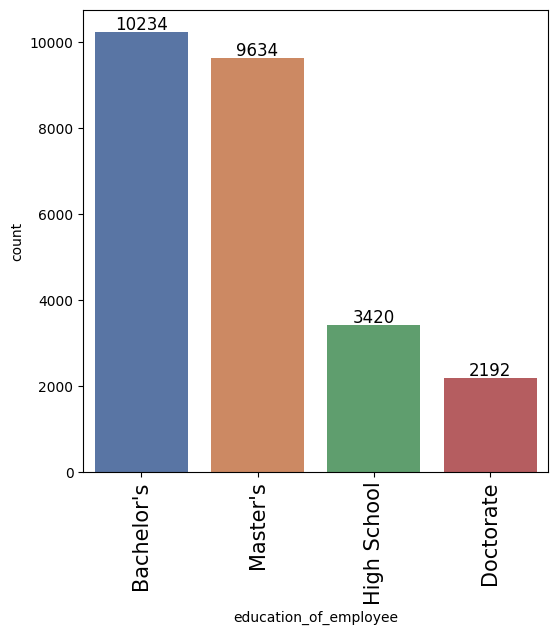

In [ ]:
labeled_barplot(df, 'education_of_employee');

##### Observations:

* The majority of employees hold a Bachelor's degree (`10234 employees`, `40.2%`), followed by a Master's degree (`9634 employees`, `37.8%`), High School Certification (`3420 employees`, `13.4%`), and a Doctorate degree (`2,192 employees`, `8.6%` of the total employees).

#### Distribution of **`has_job_experience`** *(Categorical Column)*

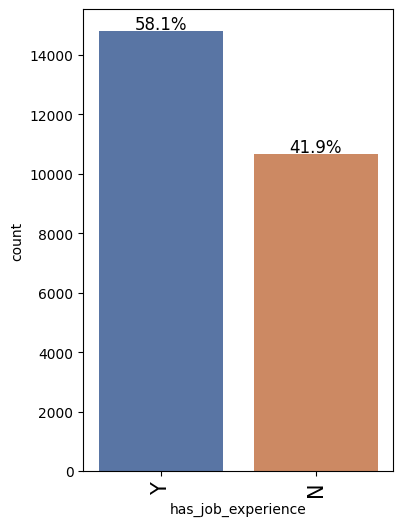

In [ ]:
labeled_barplot(df, 'has_job_experience', perc=True);

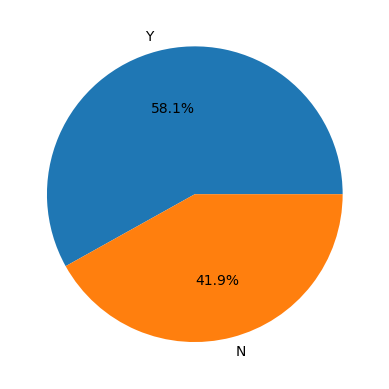

In [ ]:
plt.pie(df['has_job_experience'].value_counts(), labels=['Y', 'N'], autopct='%1.1f%%');

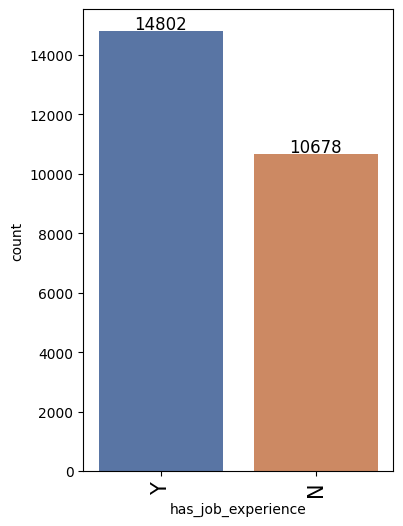

In [ ]:
labeled_barplot(df, 'has_job_experience');

##### Observations:

* The majority of employees, approximately `58.1%`, had `experience`, whereas `10,678 employees`, around `42%` of the total employees, had no job experience.

#### Distribution of **`requires_job_training`** *(Categorical Column)*

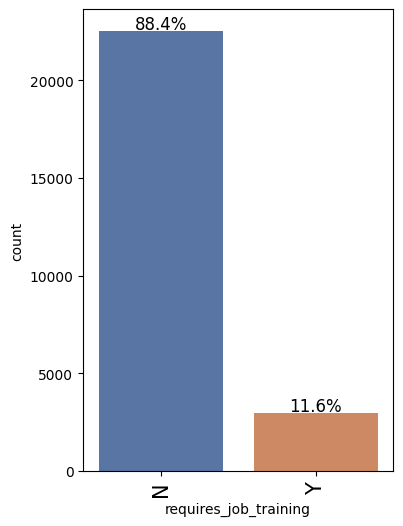

In [ ]:
labeled_barplot(df, 'requires_job_training', perc=True);

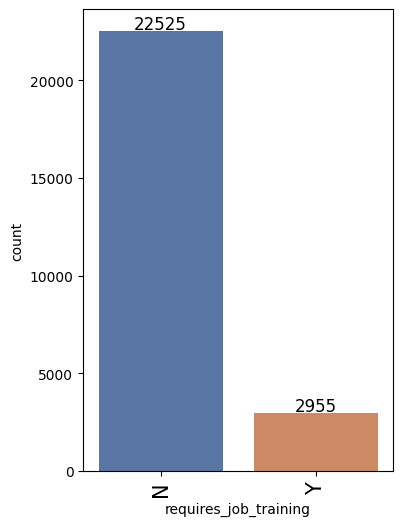

In [ ]:
labeled_barplot(df, 'requires_job_training');

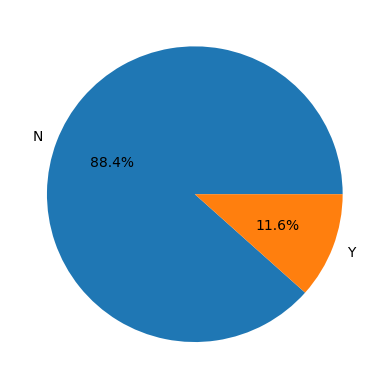

In [ ]:
plt.pie(df['requires_job_training'].value_counts(), labels=['N', 'Y'], autopct='%1.1f%%');

##### Observations:

* The majority of employees, approximately `88.4%`, did not require `job training`, whereas `10678 employees`, around `11.6%` of the total employees, required `job training`.


#### Distribution of **`region_of_employment`** *(Categorical Column)*

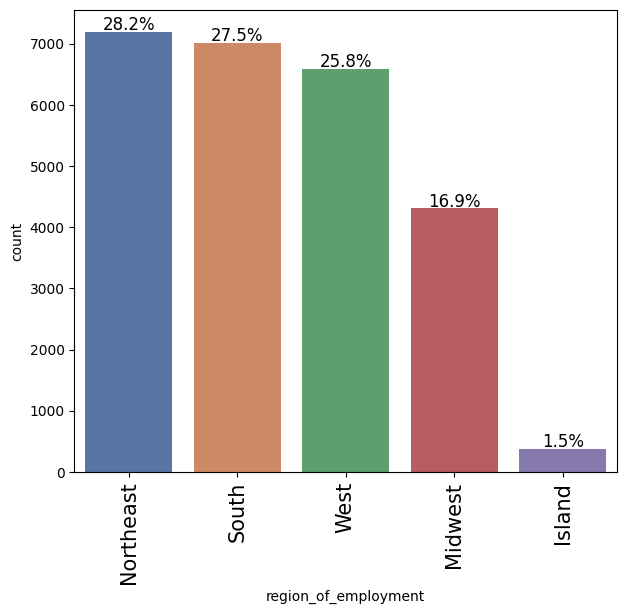

In [ ]:
labeled_barplot(df, 'region_of_employment', perc=True);

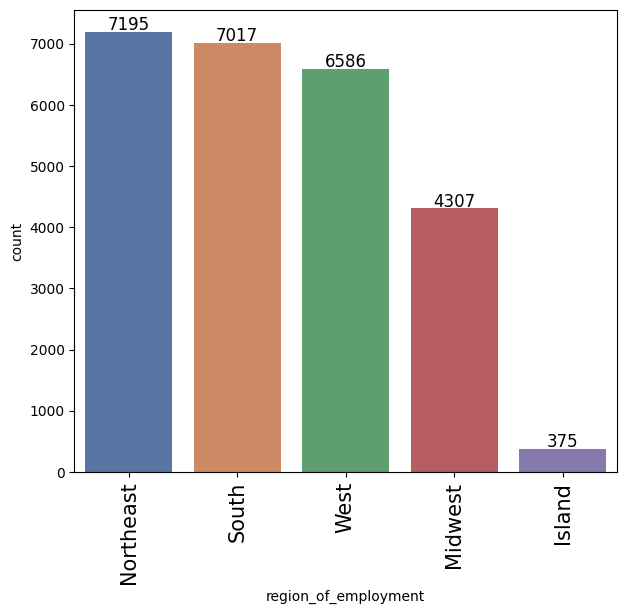

In [ ]:
labeled_barplot(df, 'region_of_employment');

##### Observations:

* The maximum number of employments were in the Northeast region (`7195 employments`, `28.2%`), followed by the South region (`7017 employments`, approximately `27.5%` of the total employments).  

* The least number of employments was in the Island region (`375 employments`, about `1.5%` of the total employments).


#### Distribution of **`unit_of_wage`** *(Categorical Column)*

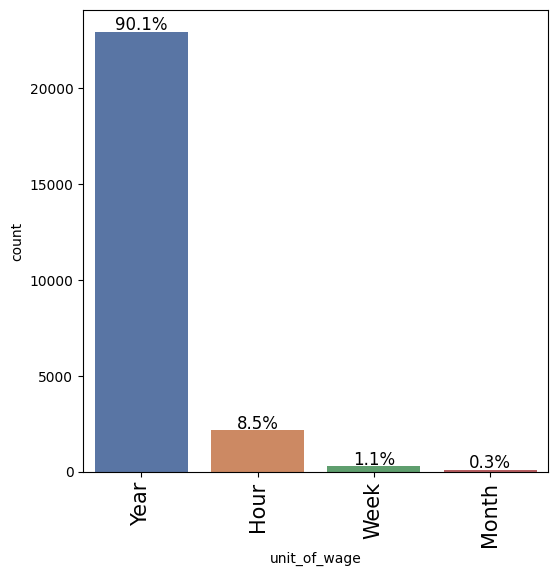

In [ ]:
labeled_barplot(df, 'unit_of_wage', perc=True);

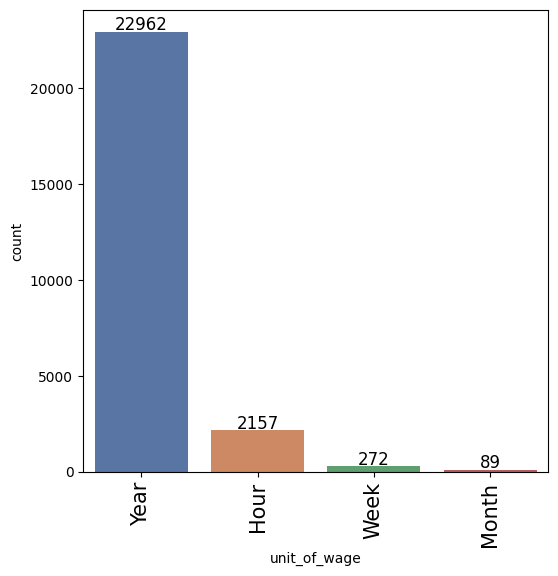

In [ ]:
labeled_barplot(df, 'unit_of_wage');

##### Observations:

- The majority of wages are recorded on a yearly basis (`22,962 records`, around `90%` of the total wages), making up the highest count.

- Hourly wages are the second most common unit with `2,157 records` (approximately `8.5%` of the total wages), significantly fewer than yearly wages.

- Weekly wages account for `272 records`, while monthly wages are the least common, with only `89 records`.


#### Distribution of **`full_time_position`** *(Categorical Column)*

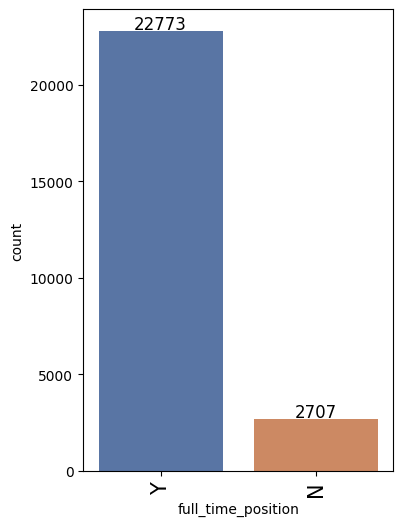

In [ ]:
labeled_barplot(df, 'full_time_position');

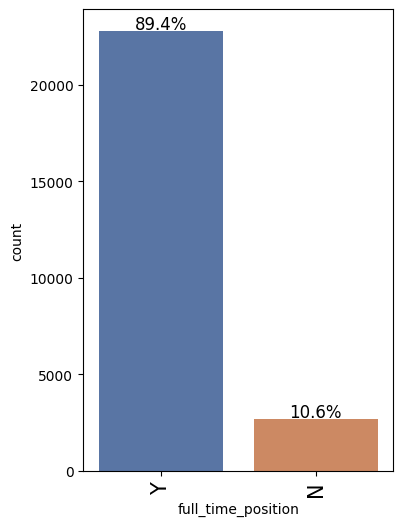

In [ ]:
labeled_barplot(df, 'full_time_position', perc=True);

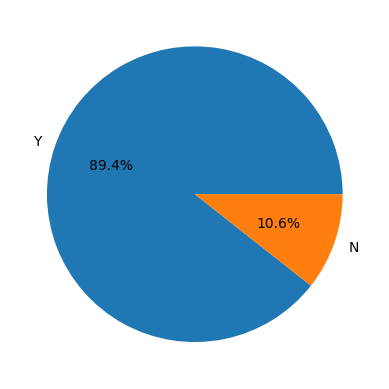

In [ ]:
plt.pie(df['full_time_position'].value_counts(), labels=['Y', 'N'], autopct='%1.1f%%');

##### Observations:

* The majority of employees wanted a full-time position (`22773 employees`, around `89.4%` of the total employees), whereas `2707 employees`, approximately `10.6%` of the total employees, did not want a full-time position.

#### Distribution of **`case_status`** *(Categorical Column)*

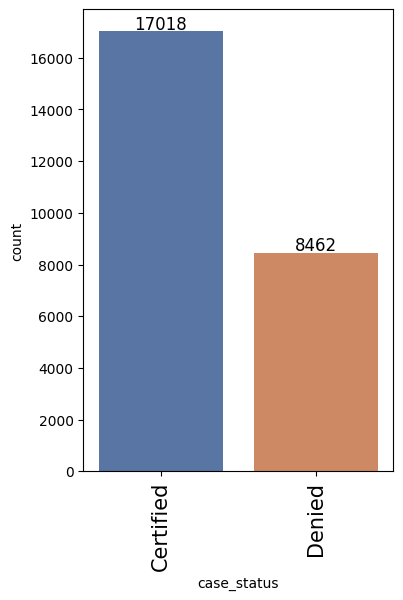

In [ ]:
labeled_barplot(df, 'case_status');

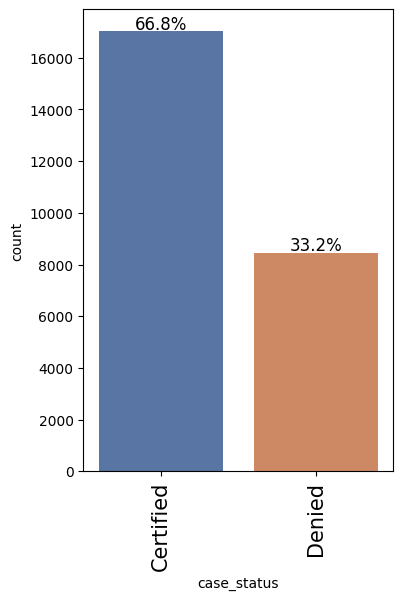

In [ ]:
labeled_barplot(df, 'case_status', perc=True);

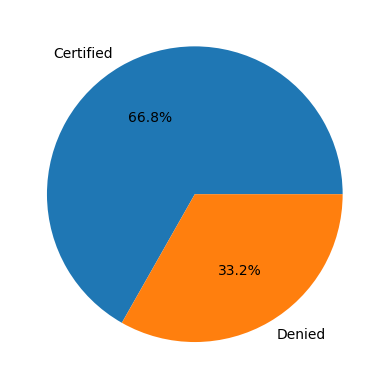

In [ ]:
plt.pie(df['case_status'].value_counts(), labels=['Certified', 'Denied'], autopct='%1.1f%%');

##### Observations:

- The majority of visa applications were certified, with `17018 cases` accounting for approximately `66.8%` of the total.  

- A notable portion of visa applications were denied, with `8462 cases`, making up around `33.2%` of the total.



### Bivariate analysis

#### Correlation check

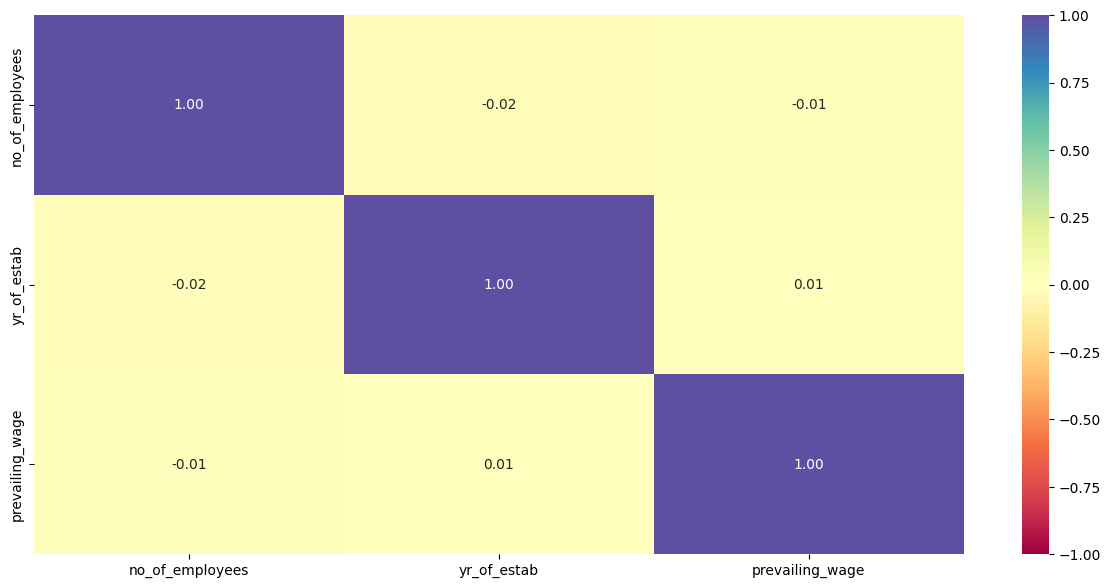

In [ ]:
# Heatmap without company_age
plt.figure(figsize=(15, 7))
sns.heatmap(df.drop('company_age', axis=1).corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

##### Observations:

- As seen in the graph, the correlations are close to zero, indicating that these numerical variables do not have a strong relationship with each other.

#### Distribution of **`case_status`** vs **`no_of_employees`** *(Categorical column & Numerical Column)*

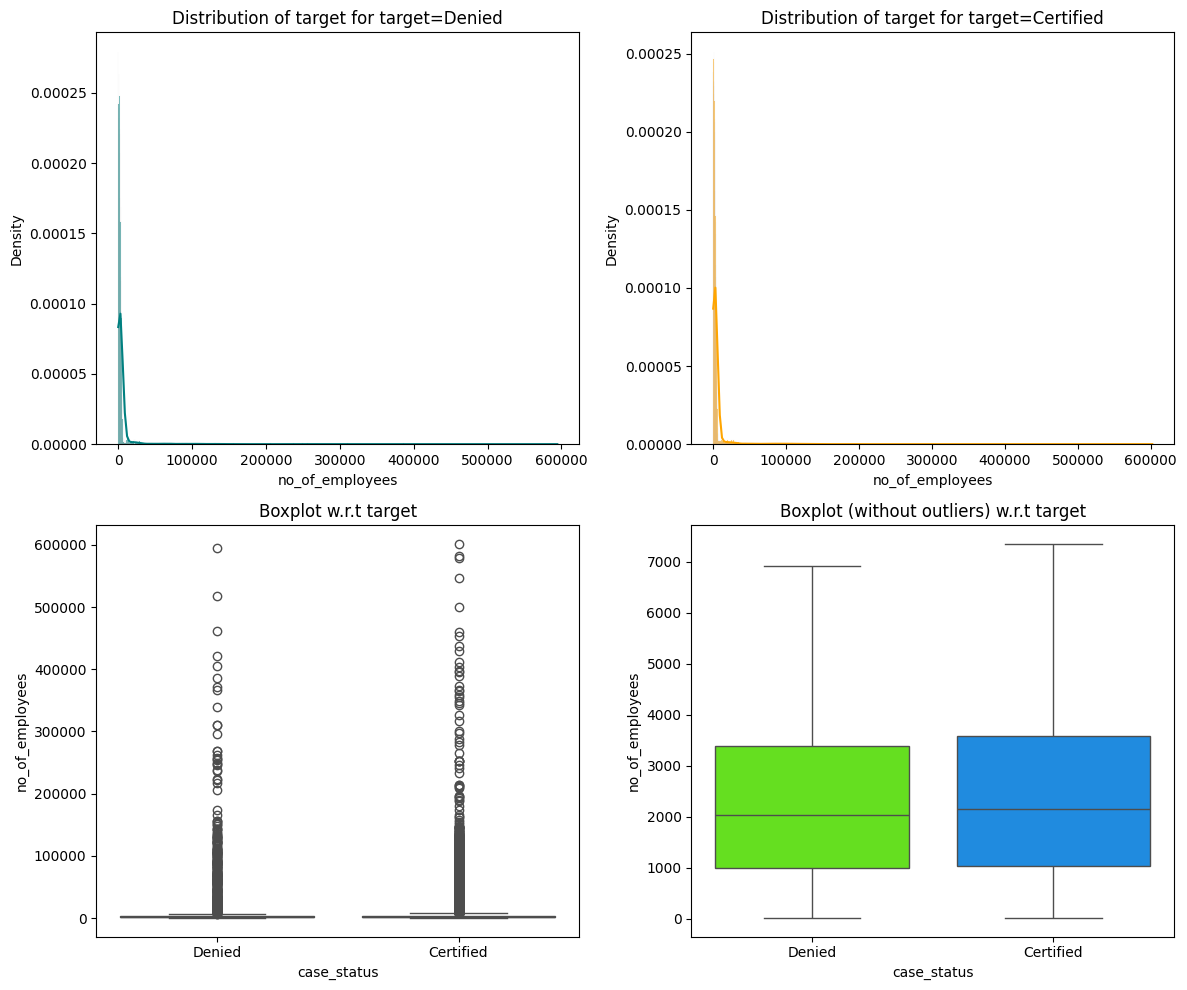

In [ ]:
distribution_plot_wrt_target(df, 'no_of_employees', 'case_status');

#### Distribution of **`case_status`** vs **`yr_of_estab`** *(Categorical column & Numerical Column)*

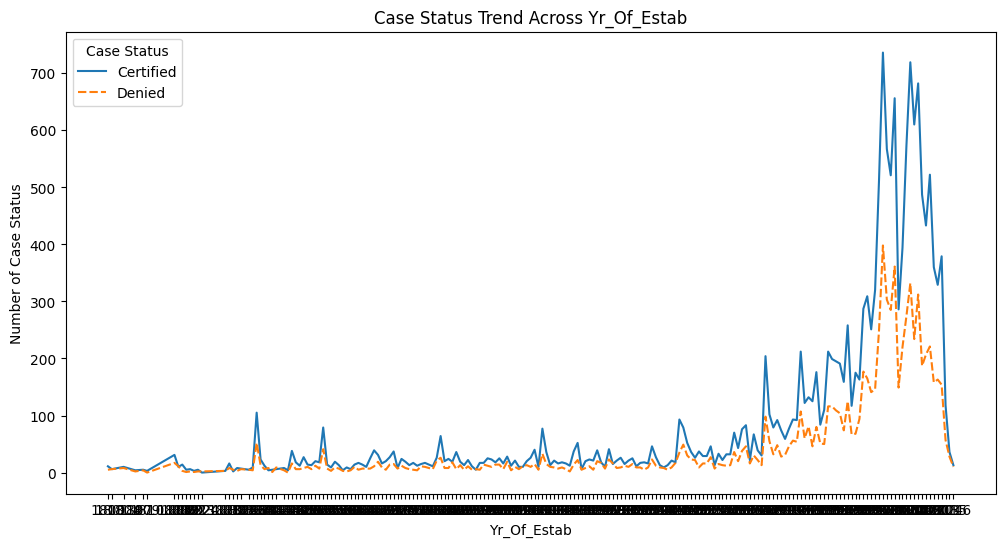

In [ ]:
line_plot_with_two_lines(df, 'yr_of_estab', 'case_status', values_col='case_id')

#### Distribution of **`case_status`** vs **`company_age`** *(Categorical column & Numerical Column)*

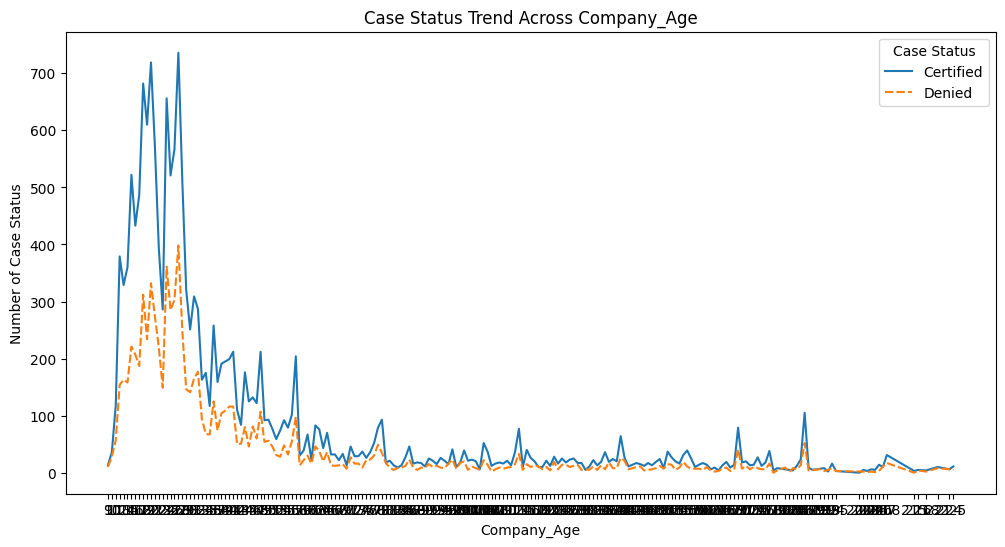

In [ ]:
line_plot_with_two_lines(df, 'company_age', 'case_status', values_col='case_id')

#### Distribution of **`case_status`** vs **`prevailing_wage`** *(Categorical column & Numerical Column)*

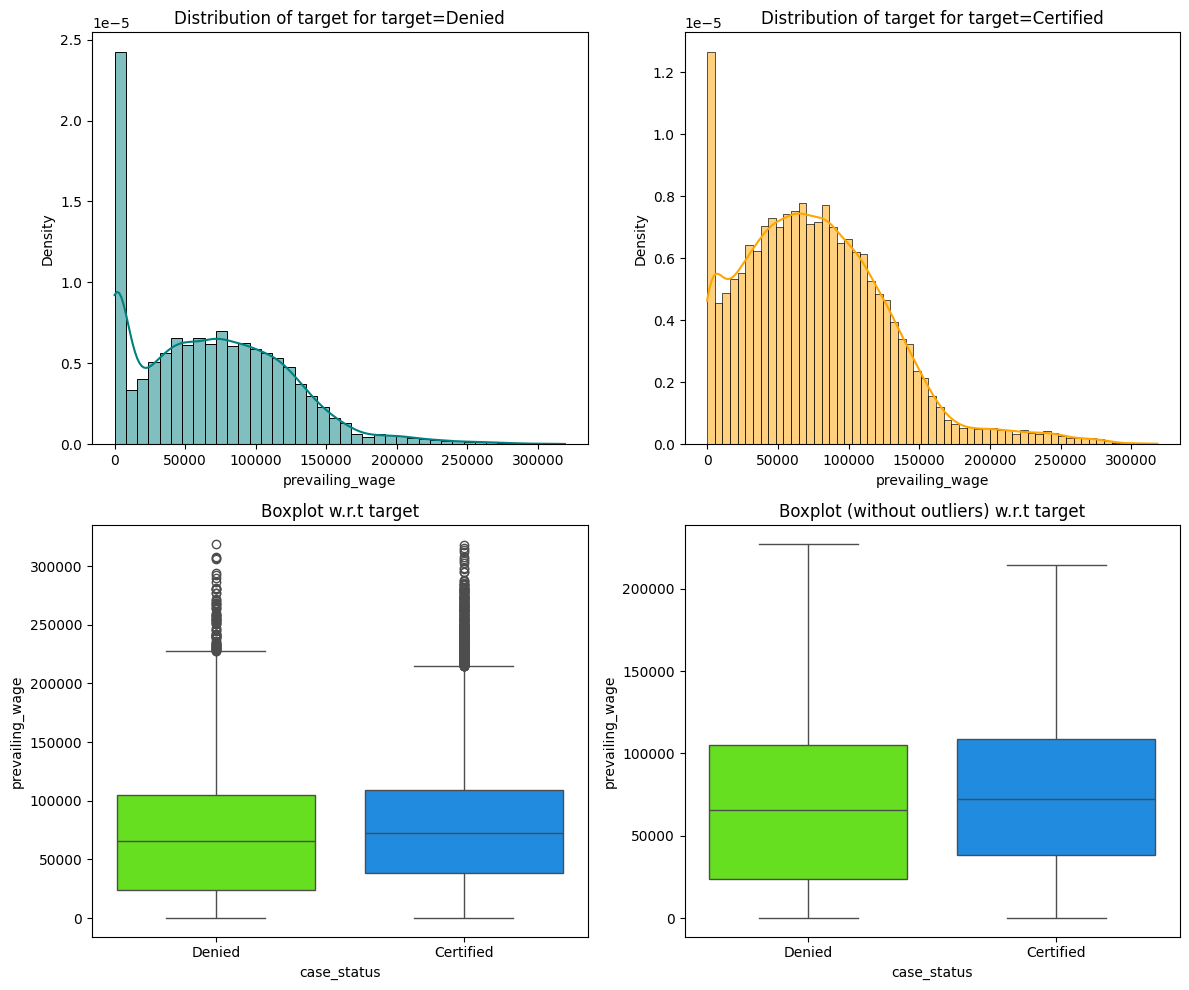

In [ ]:
distribution_plot_wrt_target(df, 'prevailing_wage', 'case_status');

##### Observations:

- The histograms indicate that the `prevailing_wage` distributions for both certified and denied visa cases are **right-skewed**, suggesting that most wages are concentrated at the lower end, with fewer cases reporting extremely high wages.

- The boxplots show that the **medians** of `prevailing_wages` are similar for both certified and denied cases, implying that wage levels may not be a key determining factor in visa outcomes.

- There are notable **outliers** in the `prevailing_wage`, especially in certified cases, as shown by the boxplot. However, excluding these outliers reveals that the **interquartile ranges** are similar, indicating that the majority of wages fall within a comparable range for both certified and denied cases.

#### Distribution of **`case_status`** vs **`continent`** *(Categorical column & Categorical Column)*

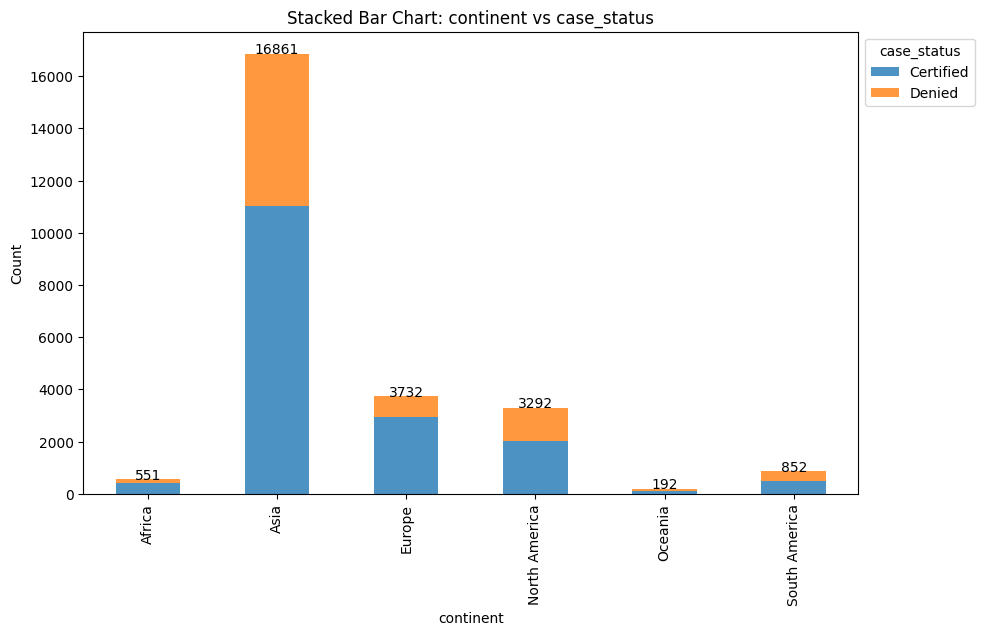

case_status,Certified,Denied,All,Denied(%),Certified(%)
continent,,,,,
Africa,397,154,551,27.95,72.05
Asia,11012,5849,16861,34.69,65.31
Europe,2957,775,3732,20.77,79.23
North America,2037,1255,3292,38.12,61.88
Oceania,122,70,192,36.46,63.54
South America,493,359,852,42.14,57.86


In [ ]:
stacked_barplot(df, 'continent', 'case_status')

##### Observations:

- The majority of employees come from `Asian Continent`, with a total of `16861 employees`. Among these, `65.31%` were *`certified`*, and `34.69%` were *`denied`*.  

- `Europe` has *`the highest percentage`* of *`certifications`* at `79.23%` and the lowest denial rate of `20.77%`.  

- `South America` has the highest denial rate at `42.14%`, with only `57.86%` of employees certified.  

- `Africa` shows `72.05%` of employees certified and `27.95%` denied.


#### Distribution of **`case_status`** vs **`education_of_employee`** *(Categorical column & Categorical Column)*

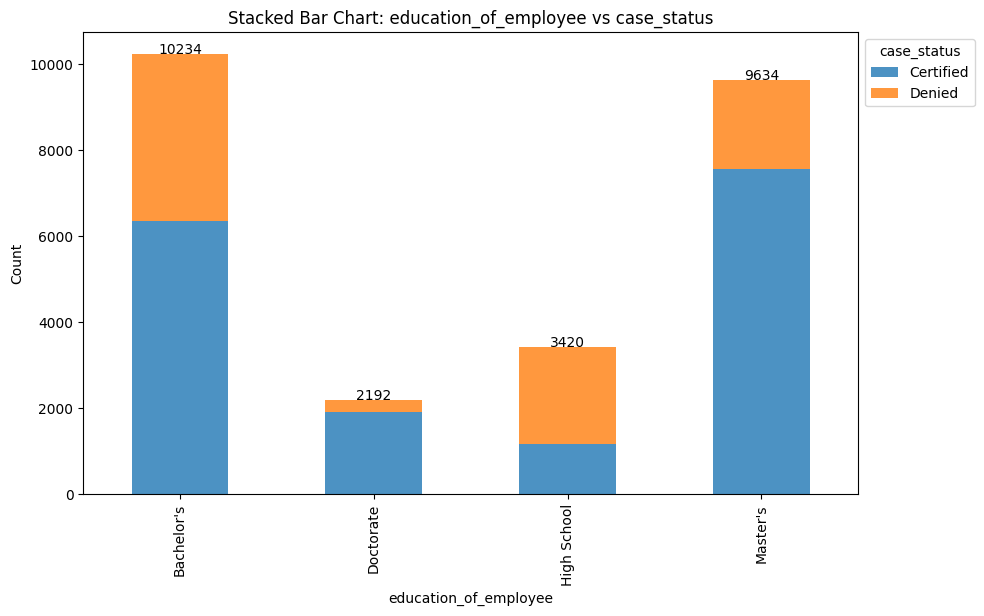

case_status,Certified,Denied,All,Denied(%),Certified(%)
education_of_employee,,,,,
Bachelor's,6367,3867,10234,37.79,62.21
Doctorate,1912,280,2192,12.77,87.23
High School,1164,2256,3420,65.96,34.04
Master's,7575,2059,9634,21.37,78.63


In [ ]:
stacked_barplot(df, 'education_of_employee', 'case_status')

##### Observations:

- The majority of employees had a *`Bachelor's degree`*, with a total of `10234 employees`. Among these, `62.21%` were *certified*, and `37.79%` were *denied*.  

- The *`highest percentage of certifications`* was observed among employees with a *`Doctorate degree`* (`87.23%`), followed by those with a *`Master's degree`* (`78.63%`), *`Bachelor's degree`* (`62.21%`), and *`High School certificate`* (`34.04%`).  

- Conversely, the *`highest percentage of denials`* occurred in reverse order: employees with a *`High School certificate`* (`65.96%`), followed by *`Bachelor's degree`* (`37.79%`), *`Master's degree`* (`21.37%`), and *`Doctorate degree`* (`12.77%`).  



#### Distribution of **`case_status`** vs **`has_job_experience`** *(Categorical column & Numerical Column)*

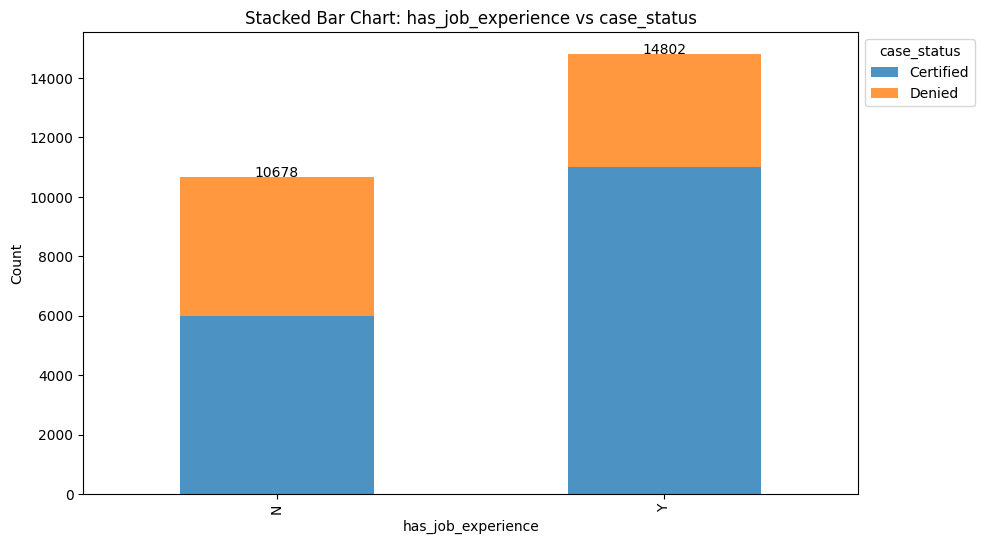

case_status,Certified,Denied,All,Denied(%),Certified(%)
has_job_experience,,,,,
N,5994,4684,10678,43.87,56.13
Y,11024,3778,14802,25.52,74.48


In [ ]:
stacked_barplot(df, 'has_job_experience', 'case_status')

##### Observations:

- The majority of employees had **experience**, with `14802 employees`, around `74.48%` of whom were *certified*, which is higher compared to employees without experience.  

- Conversely, the **highest percentage of denials** was observed among employees **without experience** (`46.87%`), whereas the denial rate for experienced employees was only `25.52%`.  



#### Distribution of **`case_status`** vs **`requires_job_training`** *(Categorical column & Numerical Column)*

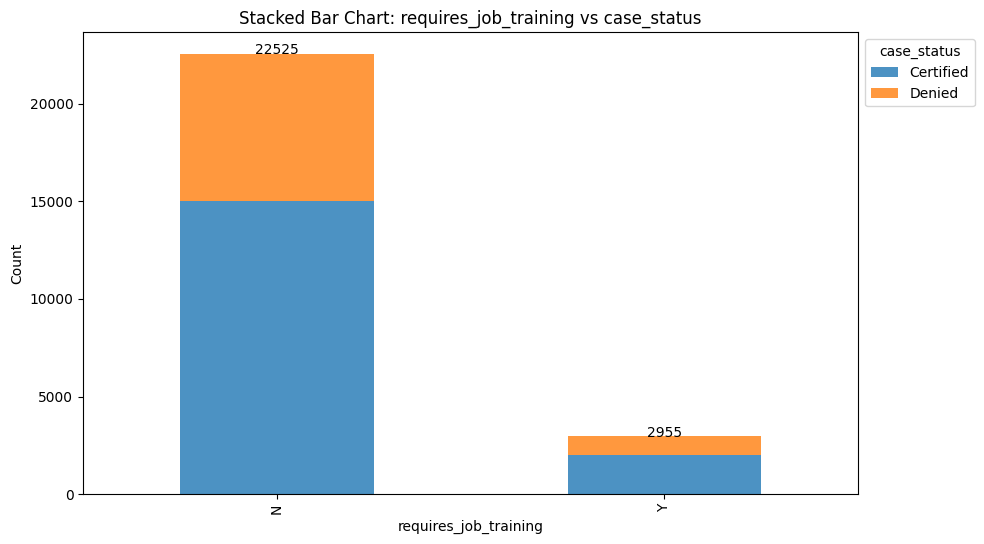

case_status,Certified,Denied,All,Denied(%),Certified(%)
requires_job_training,,,,,
N,15012,7513,22525,33.35,66.65
Y,2006,949,2955,32.12,67.88


In [ ]:
stacked_barplot(df, 'requires_job_training', 'case_status')

##### Observations:

- The majority of employees **did not require training**, with `22525 employees`, around `66.65%` of whom were *certified*, while the denial rate was `33.35%`.  

- Similarly, among employees who **required training**, `2955 employees`, around `67.88%` were *certified*, whereas the denial rate was `32.12%`.  



#### Distribution of **`case_status`** vs **`region_of_employment`** *(Categorical column & Numerical Column)*

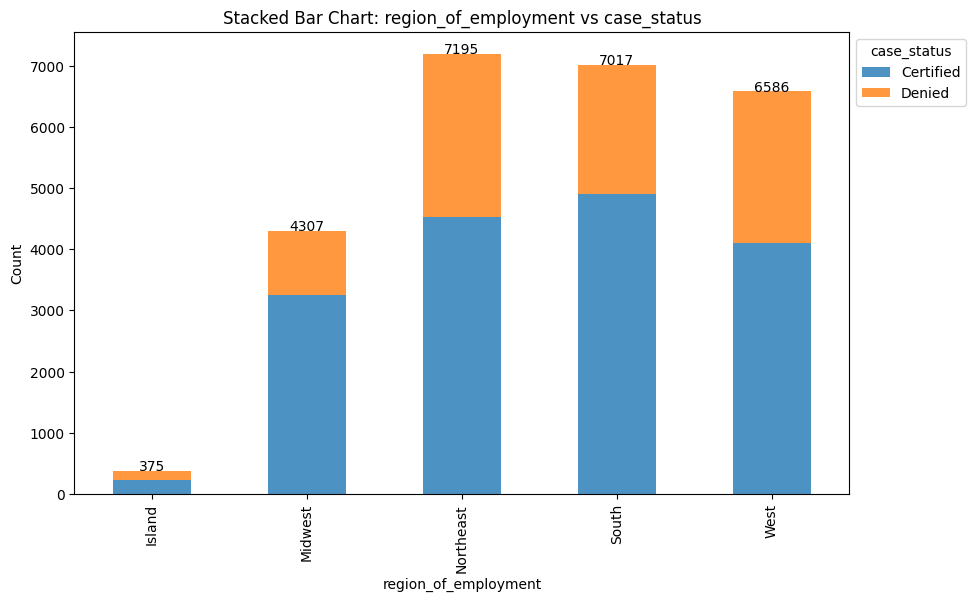

case_status,Certified,Denied,All,Denied(%),Certified(%)
region_of_employment,,,,,
Island,226,149,375,39.73,60.27
Midwest,3253,1054,4307,24.47,75.53
Northeast,4526,2669,7195,37.10,62.90
South,4913,2104,7017,29.98,70.02
West,4100,2486,6586,37.75,62.25


In [ ]:
stacked_barplot(df, 'region_of_employment', 'case_status')

##### Observations:

- **Certification Percentages:** The highest *certification percentage* was in the Midwest region, at approximately `75.53%` of the total `4307 employees`, followed by the South region with `70.02%` of `7195 employees`, among others.

- **Denial Percentages:** Conversely, the *highest denial percentage* was observed in the Northeast and West regions, both at around `37%`.



#### Distribution of **`prevailing_wage`** vs **`region_of_employment`** *(Categorical column & Numerical Column)*

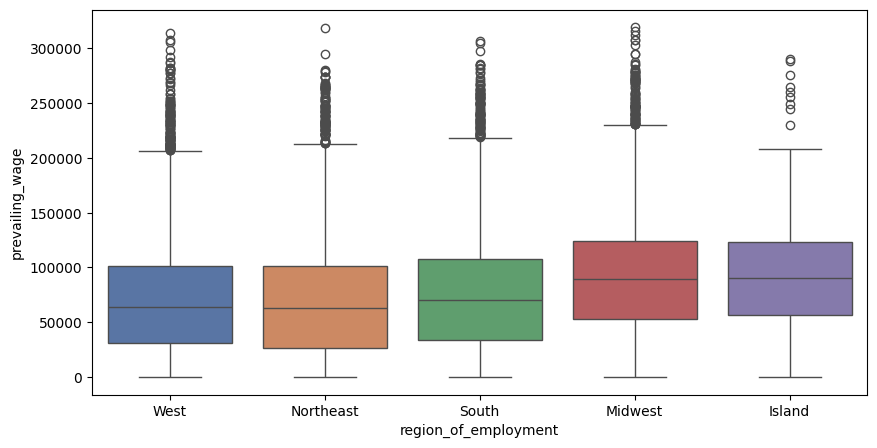

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(df, x="region_of_employment", y="prevailing_wage", palette='deep')
plt.show()

##### Observations:

* Each region shows a wide range of `prevailing_wages`, indicated by the *`long whiskers and large number of outliers`*, particularly in the `West and Midwest regions`.

* The *`median`* `prevailing_wage`, indicated by the line within the box, appears to be fairly consistent across regions.



#### Distribution of **`case_status`** vs **`unit_of_wage`** *(Categorical column & Categorical Column)*

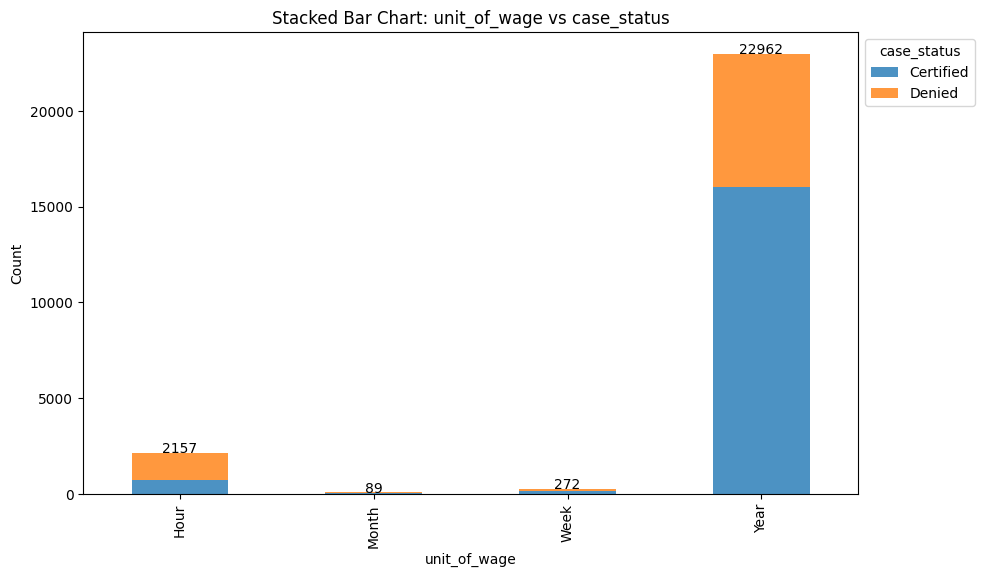

case_status,Certified,Denied,All,Denied(%),Certified(%)
unit_of_wage,,,,,
Hour,747,1410,2157,65.37,34.63
Month,55,34,89,38.20,61.80
Week,169,103,272,37.87,62.13
Year,16047,6915,22962,30.11,69.89


In [ ]:
stacked_barplot(df, 'unit_of_wage', 'case_status')

##### Observations:

- **Certification Percentages:** The highest *certification percentage* was for Yearly wages, at approximately `70%` of the total `22962 employees`, followed by Weekly wages with `62.12%` of `272 employees`, among others.

- **Denial Percentages:** The *highest denial percentage* was observed in Hourly wages, around `65.37%`, followed by Monthly wages at approximately `38%`.




#### Distribution of **`case_status`** vs **`full_time_position`** *(Categorical column & Numerical Column)*

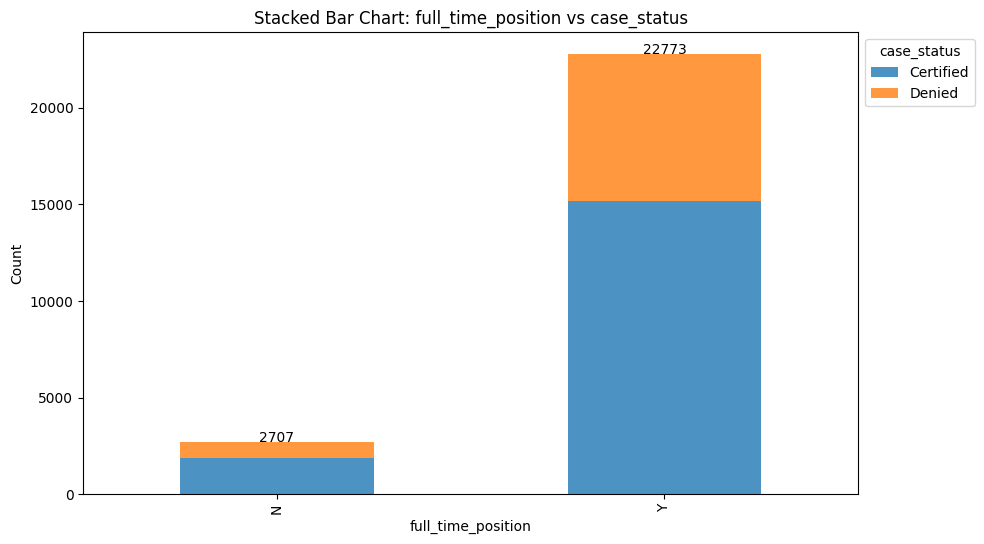

case_status,Certified,Denied,All,Denied(%),Certified(%)
full_time_position,,,,,
N,1855,852,2707,31.47,68.53
Y,15163,7610,22773,33.42,66.58


In [ ]:
stacked_barplot(df, 'full_time_position', 'case_status')

##### Observations:

- The certification percentages were nearly the same in both cases: employees who wanted a full-time position (approximately `66.58%`) and those who did not want full-time positions (around `68.53%`).


#### Distribution of **`education_of_employee`** vs **`region_of_employment`** *(Categorical column & Categorical Column)*

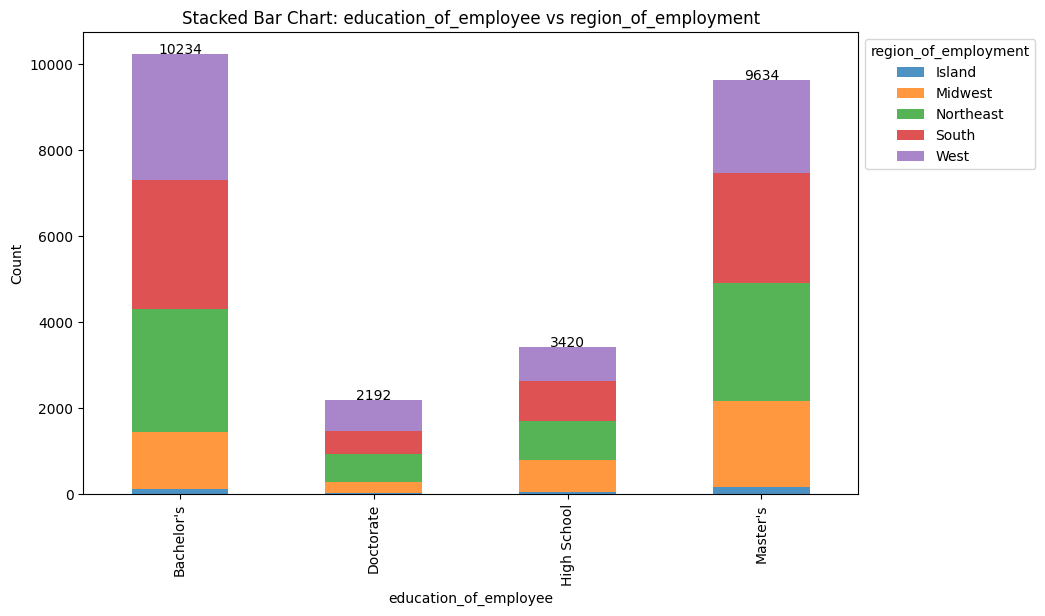

region_of_employment,Island,Midwest,Northeast,South,West,All
education_of_employee,,,,,,
Bachelor's,129,1315,2874,2991,2925,10234
Doctorate,25,256,656,541,714,2192
High School,60,736,905,934,785,3420
Master's,161,2000,2760,2551,2162,9634


In [ ]:
stacked_barplot(df, 'education_of_employee', 'region_of_employment')

##### Observations:

- The highest number of applicants with a **Bachelor's degree** (10234 applicants) were seeking employment in the South (2991 applications), West (2925 applicants), and Northeast (2874 applicants) regions.

- The second highest number of applicants with a **Master's degree** (9634 applicants) were seeking employment in the Northeast (2760 applications), South (2551 applicants), and West (2162 applicants) regions.

- The least number of applicants were in the Island region (only 161 applicants), while the highest number of applicants applied in the Northeast region.


#### Distribution of **`has_job_experience`** vs **`requires_job_training`** *(Categorical column & Categorical Column)*

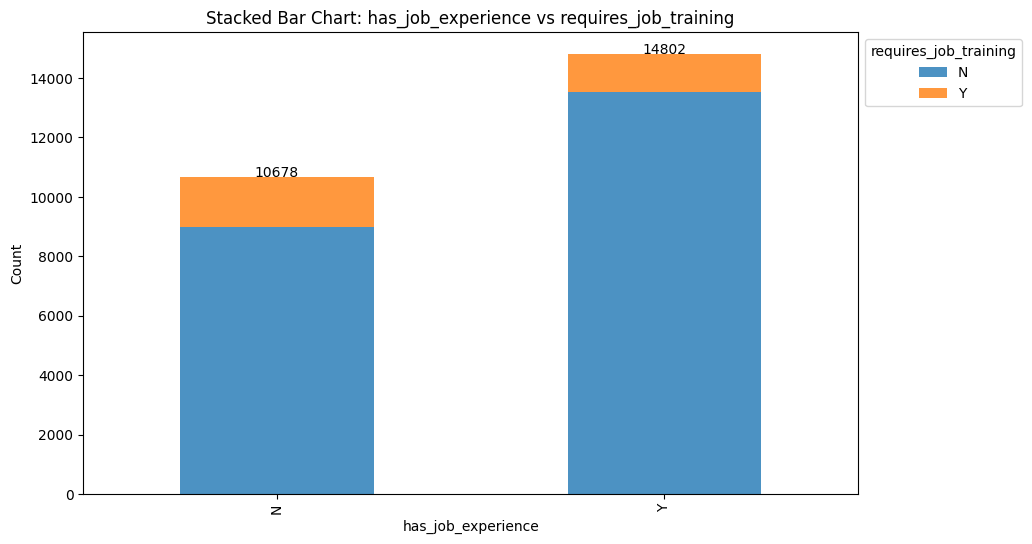

requires_job_training,N,Y,All
has_job_experience,,,
N,8988,1690,10678
Y,13537,1265,14802


In [ ]:
stacked_barplot(df, 'has_job_experience', 'requires_job_training')

##### Observations:

* A majority of applicants, both with and without job experience, do not require job training. There are a total of `13527 applicants` who do not require job training (`13537` with experience and `1690` without experience).

* Among those who do not have job experience, a larger proportion require job training. Specifically, `1690` applicants without job experience require training, compared to `1265` applicants with job experience who require training.


## **Questions**

#### **Q1 Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?**

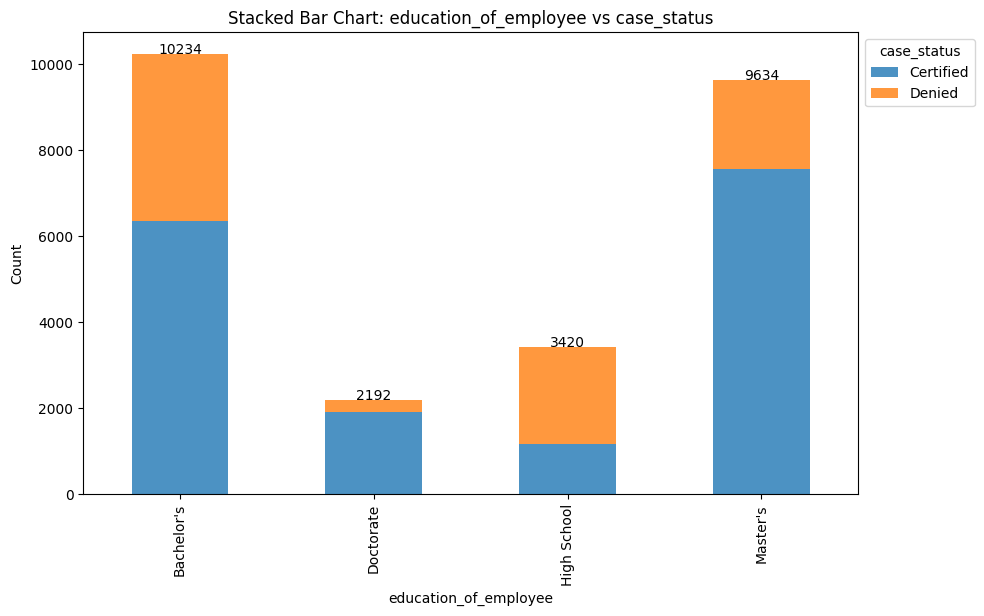

case_status,Certified,Denied,All,Denied(%),Certified(%)
education_of_employee,,,,,
Bachelor's,6367,3867,10234,37.79,62.21
Doctorate,1912,280,2192,12.77,87.23
High School,1164,2256,3420,65.96,34.04
Master's,7575,2059,9634,21.37,78.63


In [ ]:
stacked_barplot(df, 'education_of_employee', 'case_status')

##### Observations:

- As per the above data and graph, `the answer is` **`Yes`** higher education plays a role in visa certification.

- The **highest percentage of certifications** was observed among employees with a **Doctorate degree** (`87.23%`), followed by those with a **Master's degree** (`78.63%`), **Bachelor's degree** (`62.21%`), and **High School certificate** (`34.04%`).

#### **Q2 How does the visa status vary across different continents?**

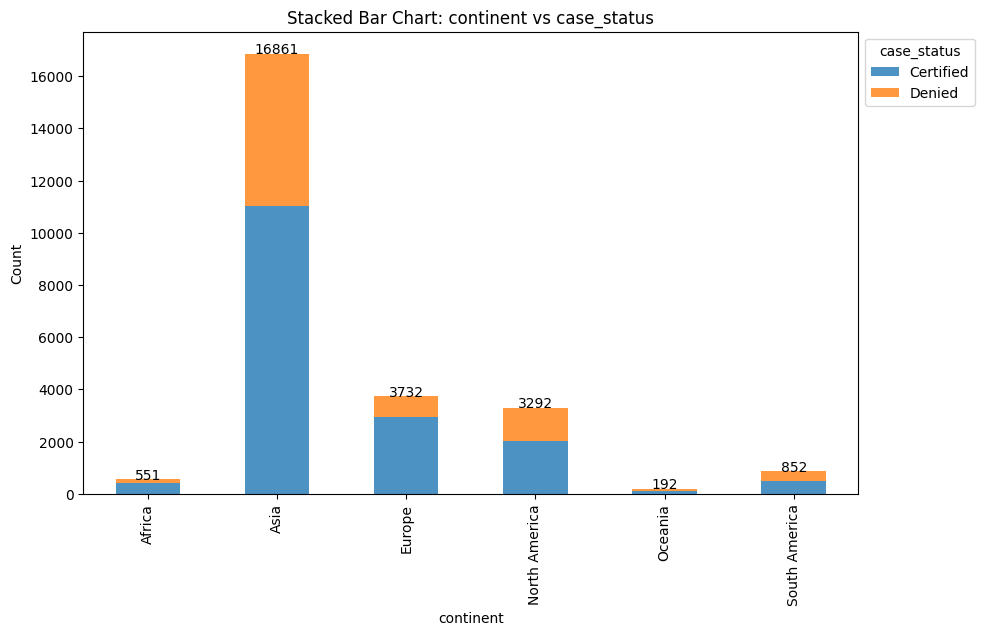

case_status,Certified,Denied,All,Denied(%),Certified(%)
continent,,,,,
Africa,397,154,551,27.95,72.05
Asia,11012,5849,16861,34.69,65.31
Europe,2957,775,3732,20.77,79.23
North America,2037,1255,3292,38.12,61.88
Oceania,122,70,192,36.46,63.54
South America,493,359,852,42.14,57.86


In [ ]:
stacked_barplot(df, 'continent', 'case_status')

##### Observations:

- The majority of employees come from `Asia Continent`, with a total of `16861 employees`. Among these, `65.31%` were *`certified`*, and `34.69%` were *`denied`*.  

- `Europe` has *`the highest percentage`* of *`certifications`* at `79.23%` and the lowest denial rate of `20.77%`.  

- `South America` has the highest denial rate at `42.14%`, with only `57.86%` of employees certified.  

- `Africa` shows `72.05%` of employees certified and `27.95%` denied.


- `North America` has a high denial rate of `38.12%`, with `61.88%` of cases certified.  

- `Oceania` has a certification rate of `63.54%` and a denial rate of `36.46%`.  



#### **Q3 Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?**

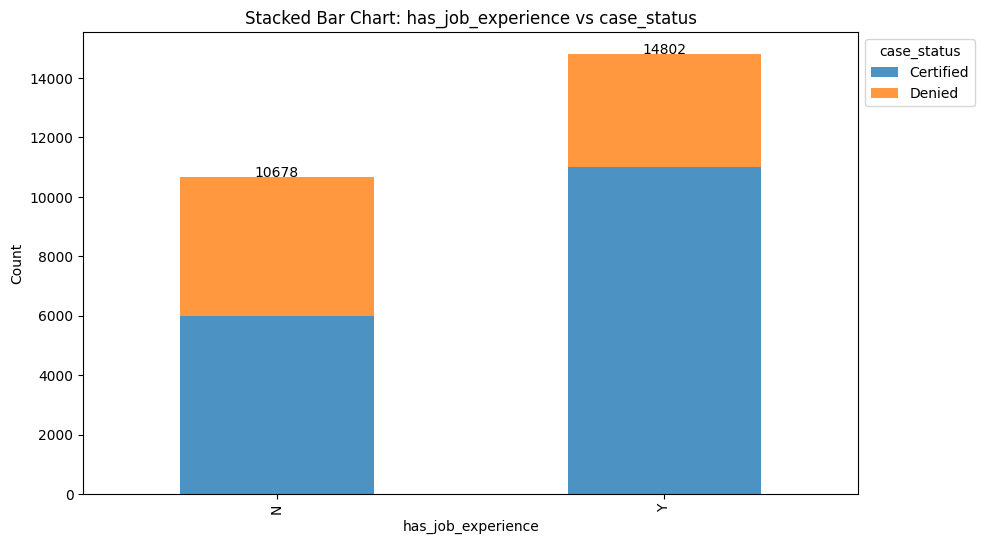

case_status,Certified,Denied,All,Denied(%),Certified(%)
has_job_experience,,,,,
N,5994,4684,10678,43.87,56.13
Y,11024,3778,14802,25.52,74.48


In [ ]:
stacked_barplot(df, 'has_job_experience', 'case_status')

##### Observations:

- As per the above data and graph, `the answer is` **`Yes`** work experience influence visa status.

- The majority of employees had **experience**, with `14802 employees`, around `74.48%` of whom were *certified*, which is higher compared to employees without experience.  

- Conversely, the **highest percentage of denials** was observed among employees **without experience** (`46.87%`), whereas the denial rate for experienced employees was only `25.52%`.  



#### **Q4 In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?**

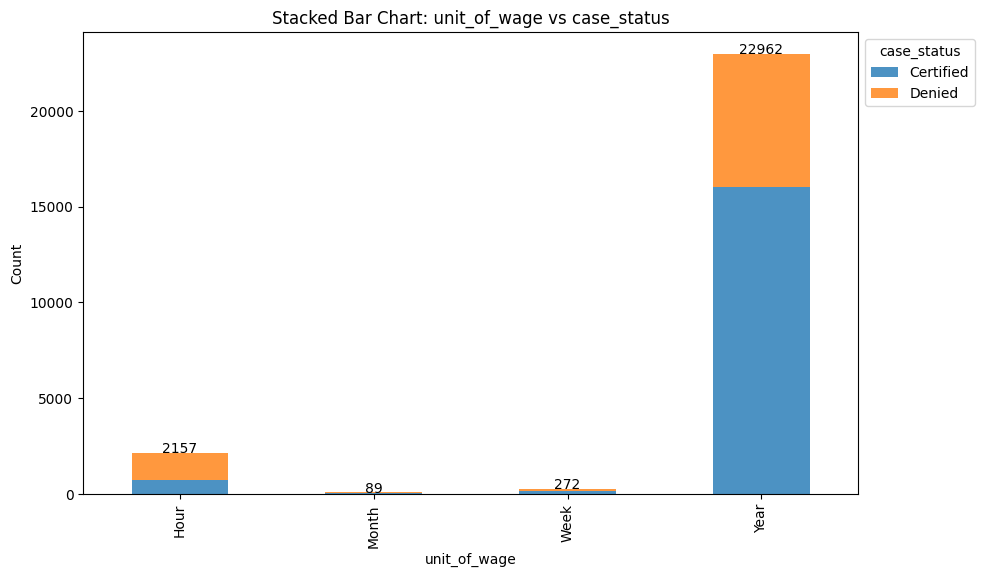

case_status,Certified,Denied,All,Denied(%),Certified(%)
unit_of_wage,,,,,
Hour,747,1410,2157,65.37,34.63
Month,55,34,89,38.20,61.80
Week,169,103,272,37.87,62.13
Year,16047,6915,22962,30.11,69.89


In [ ]:
stacked_barplot(df, 'unit_of_wage', 'case_status')

##### Observations:

- **Certification Percentages:** The highest *certification percentage* was for Yearly wages, at approximately `70%` of the total `22962 employees`, followed by Weekly wages with `62.12%` of `272 employees`, among others.

#### **Q5 The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?**

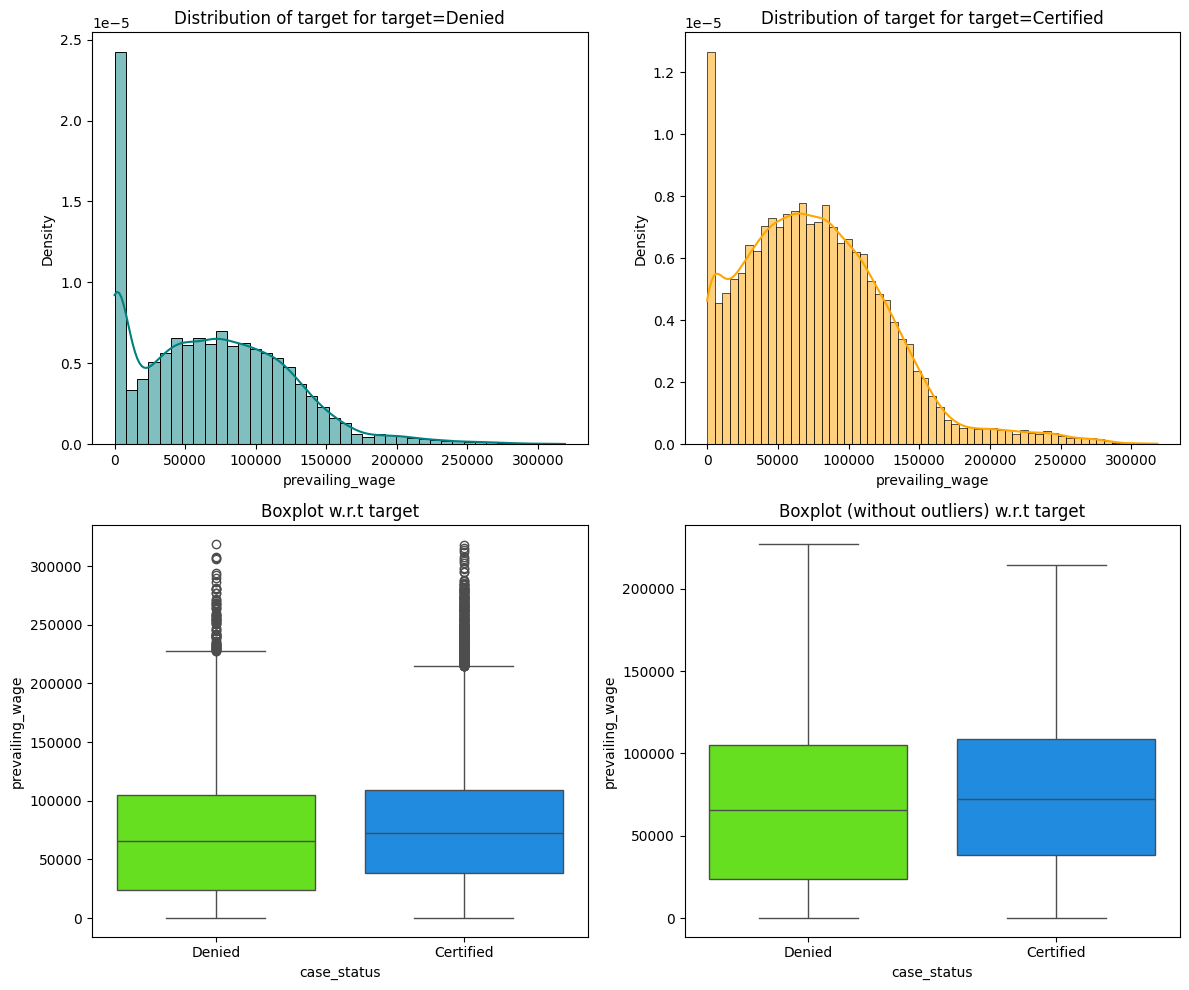

In [ ]:
distribution_plot_wrt_target(df, 'prevailing_wage', 'case_status');

##### Observations:

- `Prevailing wage distributions` for both certified and denied visa cases are right-skewed, indicating most wages are on the lower end with a few high wages.

- `Medians` of prevailing wages are similar between certified and denied cases, suggesting that wage levels alone may not be the determining factor in visa status.

- There are significant `outliers` in the certified cases, but excluding these outliers shows that most wages fall within similar ranges for both case statuses.

## **Data Preprocessing**

#### **Checking for null values**

In [ ]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


##### Observations:
* As we can see, all the columns has `0 missing values`. It means, there are no missing values in the dataset.

#### **Dropping the column (case_id) from the data frame**

In [ ]:
df.case_id.nunique()

25480

##### Observations:

- The `case_id` column contains only unique values and does not contribute to predictive modeling, so it can be dropped.

In [ ]:
print(f"Before droping: {df.shape}")

Before droping: (25480, 13)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
 12  company_age            25480 non-null  int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 2.5+ MB


In [ ]:
# As the case id has unique values, we can drop the case_id column from the data frame.
df = df.drop(labels="case_id", axis=1)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,20


In [ ]:
df.shape

(25480, 12)

##### Observations:
* There are *`12 columns`* (Previously 13 columns) in new data frame.

#### **Treat Outliers**

* All the values smaller than the lower whisker will be assigned the value of the lower whisker, and all the values above the upper whisker will be assigned the value of the upper whisker.

In [ ]:
# functions to treat outliers by flooring and capping

def treat_outliers_all(df, col_list):
    """
    Treat outliers in a list of variables

    df: dataframe
    col_list: list of dataframe columns
    """
    for c in col_list:
        df = treat_outliers(df, c)

    return df


def treat_outliers(df, col):
    """
    Treats outliers in a variable

    df: dataframe
    col: dataframe column
    """
    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1
    Lower_Whisker = Q1 - 1.5 * IQR
    Upper_Whisker = Q3 + 1.5 * IQR

    # all the values smaller than Lower_Whisker will be assigned the value of Lower_Whisker
    # all the values greater than Upper_Whisker will be assigned the value of Upper_Whisker
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker)

    return df

#### Outlier Detection

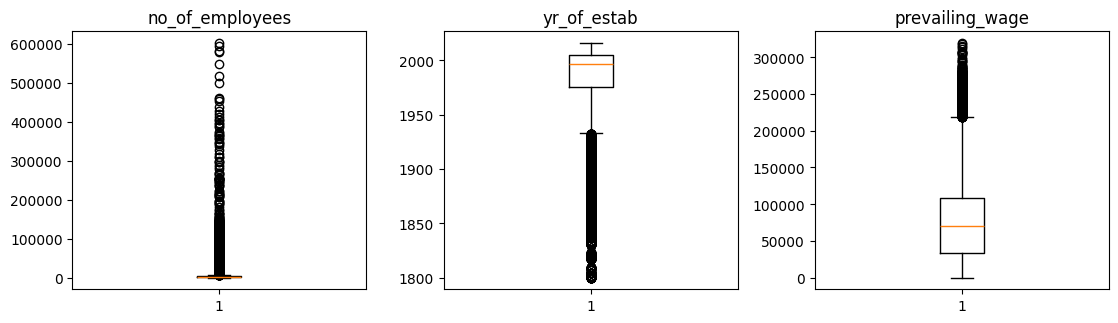

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

##### Observations

- Outliers in `no_of_employees` and `yr_of_establishment` are expected, as some companies may have an exceptionally large workforce, while others are much smaller, and the establishment year can vary significantly, with some companies being much older or newer than average.

- The distribution of `prevailing_wage` remained consistent even after removing outliers.

- These outliers provide meaningful insights into the diversity and variability within the dataset.

- Therefore, we will `include the outliers` in our analysis, as they hold valuable information.

#### **Feature Engineering**

##### Encoading Categorical Variables

In [ ]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,20


In [ ]:
# Convert Certified case_status to 1 and Denied to 0
df['case_status'] = df['case_status'].apply( lambda x: 1 if x=='Certified' else 0)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,0,18
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,1,23
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,0,17
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,0,128
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,1,20


##### **Data Preparation**

In [ ]:
# specifying the independent  and dependent variables
X = df.drop(['case_status'], axis=1)
Y = df['case_status']

# creating dummy variables
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True,)
X.shape

(25480, 22)

##### **Train-Test Split**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

print("{0:0.2f}% of the data is allocated to the training set.".format((len(X_train)/len(df.index)) * 100))
print("{0:0.2f}% of the data is allocated to the test set.".format((len(X_test)/len(df.index)) * 100))

70.00% of the data is allocated to the training set.
30.00% of the data is allocated to the test set.


In [ ]:
print('Shape of the training set:', X_train.shape[0])
print('Shape of test set:', X_test.shape[0])
print()
print("-"*50)
print('Percentage of Classes in Training Set:', Y_train.value_counts(normalize=True))
print()
print("-"*50)
print('Percentage of Classes in Test Set:', Y_test.value_counts(normalize=True))

Shape of the training set: 17836
Shape of test set: 7644

--------------------------------------------------
Percentage of Classes in Training Set: case_status
1    0.663602
0    0.336398
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set: case_status
1    0.677917
0    0.322083
Name: proportion, dtype: float64


In [ ]:
X.head()

,no_of_employees,yr_of_estab,prevailing_wage,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
0,14513,2007,592.2029,18,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
1,2412,2002,83425.6500,23,True,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,True,True
2,44444,2008,122996.8600,17,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,True
3,98,1897,83434.0300,128,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
4,1082,2005,149907.3900,20,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,True


In [ ]:
Y.head()

,case_status
0,0
1,1
2,0
3,0
4,1


In [ ]:
# Making sure our data is of type float.
X = X.astype(float)
X.head()

,no_of_employees,yr_of_estab,prevailing_wage,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
0,14513.0,2007.0,592.2029,18.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2412.0,2002.0,83425.6500,23.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,44444.0,2008.0,122996.8600,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,98.0,1897.0,83434.0300,128.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,1082.0,2005.0,149907.3900,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   no_of_employees                    25480 non-null  float64
 1   yr_of_estab                        25480 non-null  float64
 2   prevailing_wage                    25480 non-null  float64
 3   company_age                        25480 non-null  float64
 4   continent_Asia                     25480 non-null  float64
 5   continent_Europe                   25480 non-null  float64
 6   continent_North America            25480 non-null  float64
 7   continent_Oceania                  25480 non-null  float64
 8   continent_South America            25480 non-null  float64
 9   education_of_employee_Doctorate    25480 non-null  float64
 10  education_of_employee_High School  25480 non-null  float64
 11  education_of_employee_Master's     25480 non-null  flo

#### **Spliting the data**

In [ ]:
# We will use 70% of data for training and 30% for testing.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

print("{0:0.2f}% of the data is allocated to the training set.".format((len(X_train)/len(df.index)) * 100))
print("{0:0.2f}% of the data is allocated to the test set.".format((len(X_test)/len(df.index)) * 100))

70.00% of the data is allocated to the training set.
30.00% of the data is allocated to the test set.


In [ ]:
print('Shape of the training set:', X_train.shape[0])
print('Shape of test set:', X_test.shape[0])
print()
print("-"*50)
print('Percentage of Classes in Training Set:', Y_train.value_counts(normalize=True))
print()
print("-"*50)
print('Percentage of Classes in Test Set:', Y_test.value_counts(normalize=True))

Shape of the training set: 17836
Shape of test set: 7644

--------------------------------------------------
Percentage of Classes in Training Set: case_status
1    0.663602
0    0.336398
Name: proportion, dtype: float64

--------------------------------------------------
Percentage of Classes in Test Set: case_status
1    0.677917
0    0.322083
Name: proportion, dtype: float64


#### **Model Support Functions**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## **Model Building**

### **Model Evaluation Criterion**

**Model can make wrong predictions as:**
- Predicting that an applicant will not be approved for a visa (False Negative - FN), but in reality, the applicant should be approved.

- Predicting that an applicant will be approved for a visa (False Positive - FP), but in reality, the applicant should not be approved.


**Which case is more important?**

- If we predict that an applicant will not be approved but in reality, the applicant should be approved (False Negative), the visa process will be delayed or the applicant will miss the opportunity, which could be costly for both the applicant and the organization. This might lead to dissatisfied applicants, and it could have long-term consequences on the visa approval system’s reputation and efficiency.

- If we predict that an applicant will be approved but in reality, the applicant should not be approved (False Positive), the company could waste resources on unnecessary visa processing, but the impact is less severe compared to the False Negative scenario. This is because the cost of rejecting an applicant is higher than rejecting an applicant who should have been approved.


**How to reduce the losses?**

- The company would want the **recall** to be maximized because **greater recall** reduces False Negatives (FN). By maximizing recall, the model will increase the likelihood of correctly identifying applicants who should be approved for a visa.

- **Precision** should also be considered, but recall is critical in this case since it's more important not to miss qualified applicants than to prevent some false positives.


**Recommendation:**

- **Maximize recall**, as failing to approve deserving applicants has higher consequences than approving undeserving ones. While false positives should be minimized, the emphasis should be on identifying all applicants who deserve approval.


### **Decision Tree**

#### **Building Decision Tree model (default)**

In [ ]:
# Define decision tree classifier with random state = 1
dt = DecisionTreeClassifier(random_state=1)

# Fit decision tree classifier on the train data
dt.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=1)

##### Checking model performance on training set

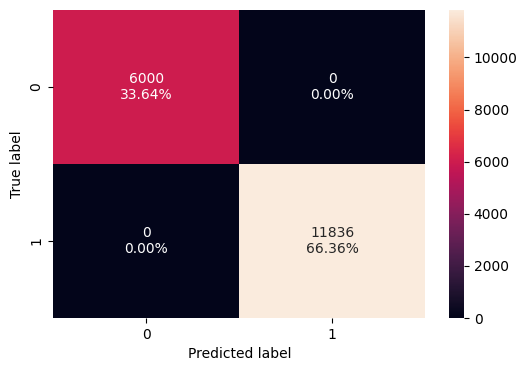

In [ ]:
confusion_matrix_sklearn(dt, X_train, Y_train)

In [ ]:
dt_perf_train = model_performance_classification_sklearn(dt, X_train, Y_train)
dt_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on test set

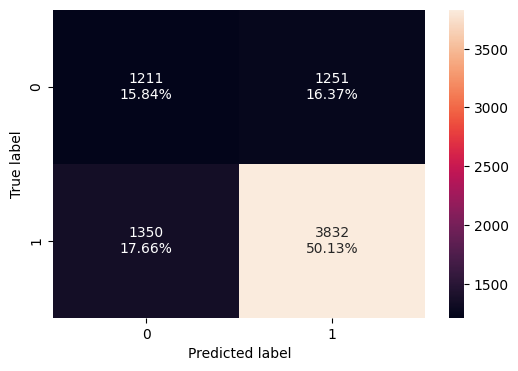

In [ ]:
confusion_matrix_sklearn(dt, X_test, Y_test)

In [ ]:
dt_perf_test = model_performance_classification_sklearn(dt, X_test, Y_test)
dt_perf_test

,Accuracy,Recall,Precision,F1
0,0.659733,0.739483,0.753886,0.746615


##### **Let's check the important features (Decision Tree: default)**

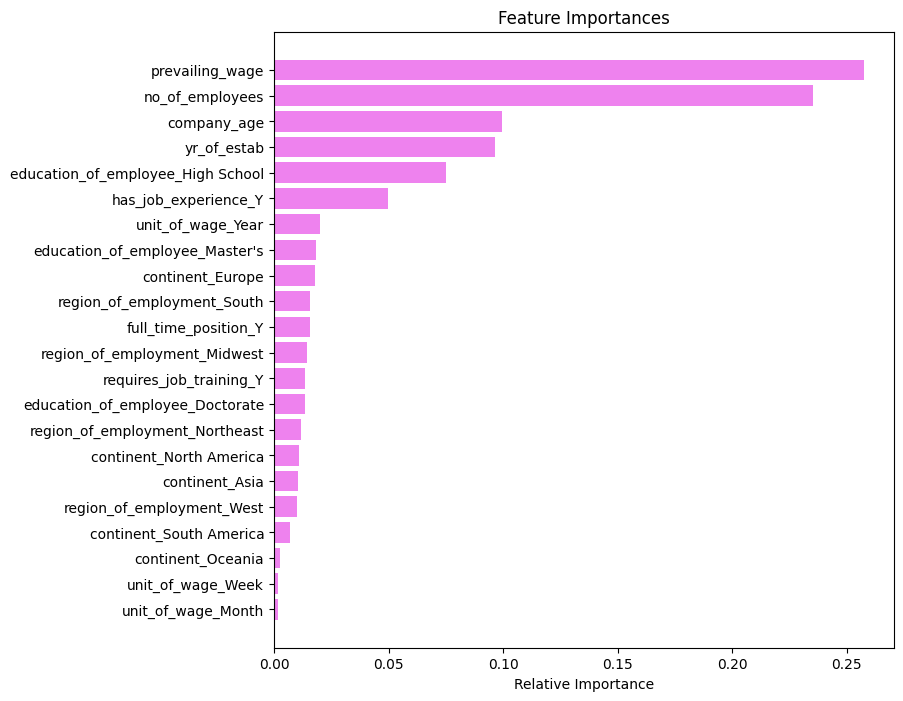

In [ ]:
feature_names = list(X_train.columns)
importances = dt.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### Observations:

- If the frequency of class A is 10% and the frequency of class B is 90%, then class B will become the dominant class and the decision tree will become biased toward the dominant classes.

- In this case, we will set `class_weight = "balanced"`, which will automatically adjust the weights to be inversely proportional to the class frequencies in the input data.

- As shown in the Feature Importance graph, **prevailing_wage** and **no_of_employees** are the most important features.

- `class_weight` is a hyperparameter for the decision tree classifier.

#### **Building Decision Tree model (with class_weight)**

In [ ]:
# Define decision tree classifier with random state = 1
dt_1 = DecisionTreeClassifier(random_state=1, class_weight="balanced")

# Fit decision tree classifier on the train data
dt_1.fit(X_train, Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

##### Checking model performance on training set

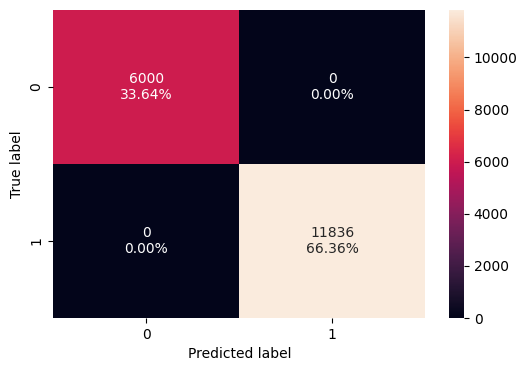

In [ ]:
confusion_matrix_sklearn(dt_1, X_train, Y_train)

In [ ]:
dt_1_perf_train = model_performance_classification_sklearn(dt_1, X_train, Y_train)
dt_1_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


##### Checking model performance on test set

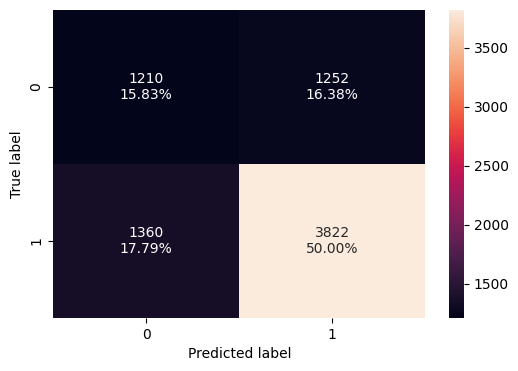

In [ ]:
confusion_matrix_sklearn(dt_1, X_test, Y_test)

In [ ]:
dt_1_perf_test = model_performance_classification_sklearn(dt_1, X_test, Y_test)
dt_1_perf_test

,Accuracy,Recall,Precision,F1
0,0.658294,0.737553,0.753252,0.74532


##### Let's check the important features:

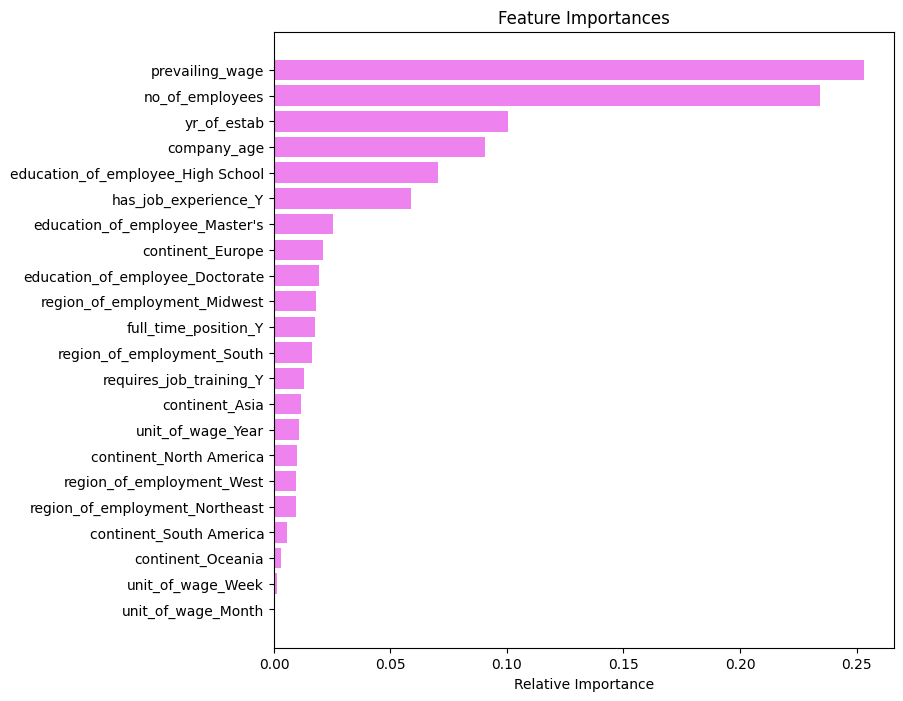

In [ ]:
feature_names = list(X_train.columns)
importances = dt_1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### Observations:

- There is a huge disparity in performance of model on training set and test set, which suggests that the model is `overfiiting`.

- As shown in the Feature Importance graph, **prevailing_wage** and **no_of_employees** are the most important features.

- Let's use `pruning techniques` to try and reduce overfitting.

#### **Building Decision Tree model (Pre-Pruning)**

* Hyperparameter tuning is crucial because it directly affects the performance of a model.
* Unlike model parameters which are learned during training, hyperparameters need to be set before training.
* Effective hyperparameter tuning helps in improving the performance and robustness of the model.
* The below custom loop for hyperparameter tuning iterates over predefined parameter values to identify the best model based on the metric of choice (recall score).

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, Y_train)

            # Make predictions on the training and test sets
            Y_train_pred = estimator.predict(X_train)
            Y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(Y_train, Y_train_pred)
            test_recall_score = recall_score(Y_test, Y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 6
Max leaf nodes: 50
Min samples split: 70
Best test recall score: 0.8002701659590892


In [ ]:
# creating an instance of the best model
model_pre_prun = best_estimator

# fitting the best model to the training data
model_pre_prun.fit(X_train, Y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, max_leaf_nodes=50,
                       min_samples_split=70, random_state=42)

##### Checking model performance on training set

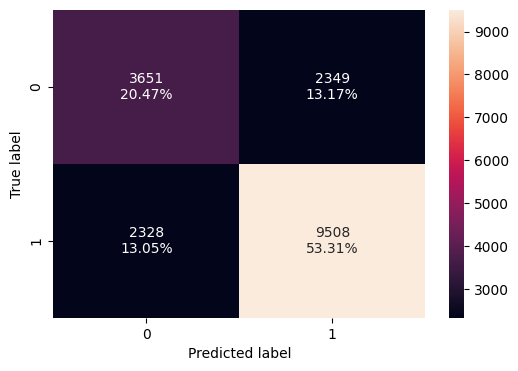

In [ ]:
confusion_matrix_sklearn(model_pre_prun, X_train, Y_train)

In [ ]:
dt_pre_prun_perf_train = model_performance_classification_sklearn(model_pre_prun, X_train, Y_train)
dt_pre_prun_perf_train

,Accuracy,Recall,Precision,F1
0,0.737778,0.803312,0.801889,0.8026


##### Checking model performance on test set

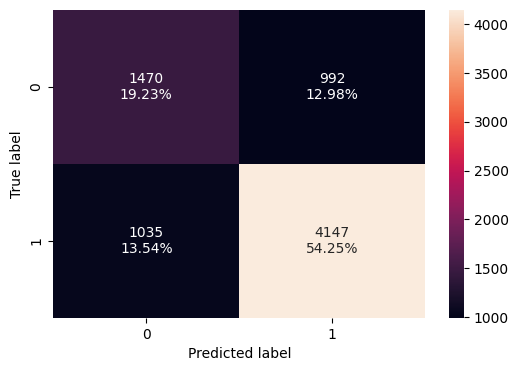

In [ ]:
confusion_matrix_sklearn(model_pre_prun, X_test, Y_test)

In [ ]:
dt_pre_prun_perf_test = model_performance_classification_sklearn(model_pre_prun, X_test, Y_test)
dt_pre_prun_perf_test

,Accuracy,Recall,Precision,F1
0,0.734825,0.80027,0.806966,0.803604


##### Observations:

* The model is giving a generalized result now since the recall scores on both the train and test data are coming to be around 0.80 which shows that the model is able to generalize well on unseen data.

##### **Decision Trees (Pre-Pruning)**

In [ ]:
feature_names = list(X_train.columns)
importances = model_pre_prun.feature_importances_
indices = np.argsort(importances)

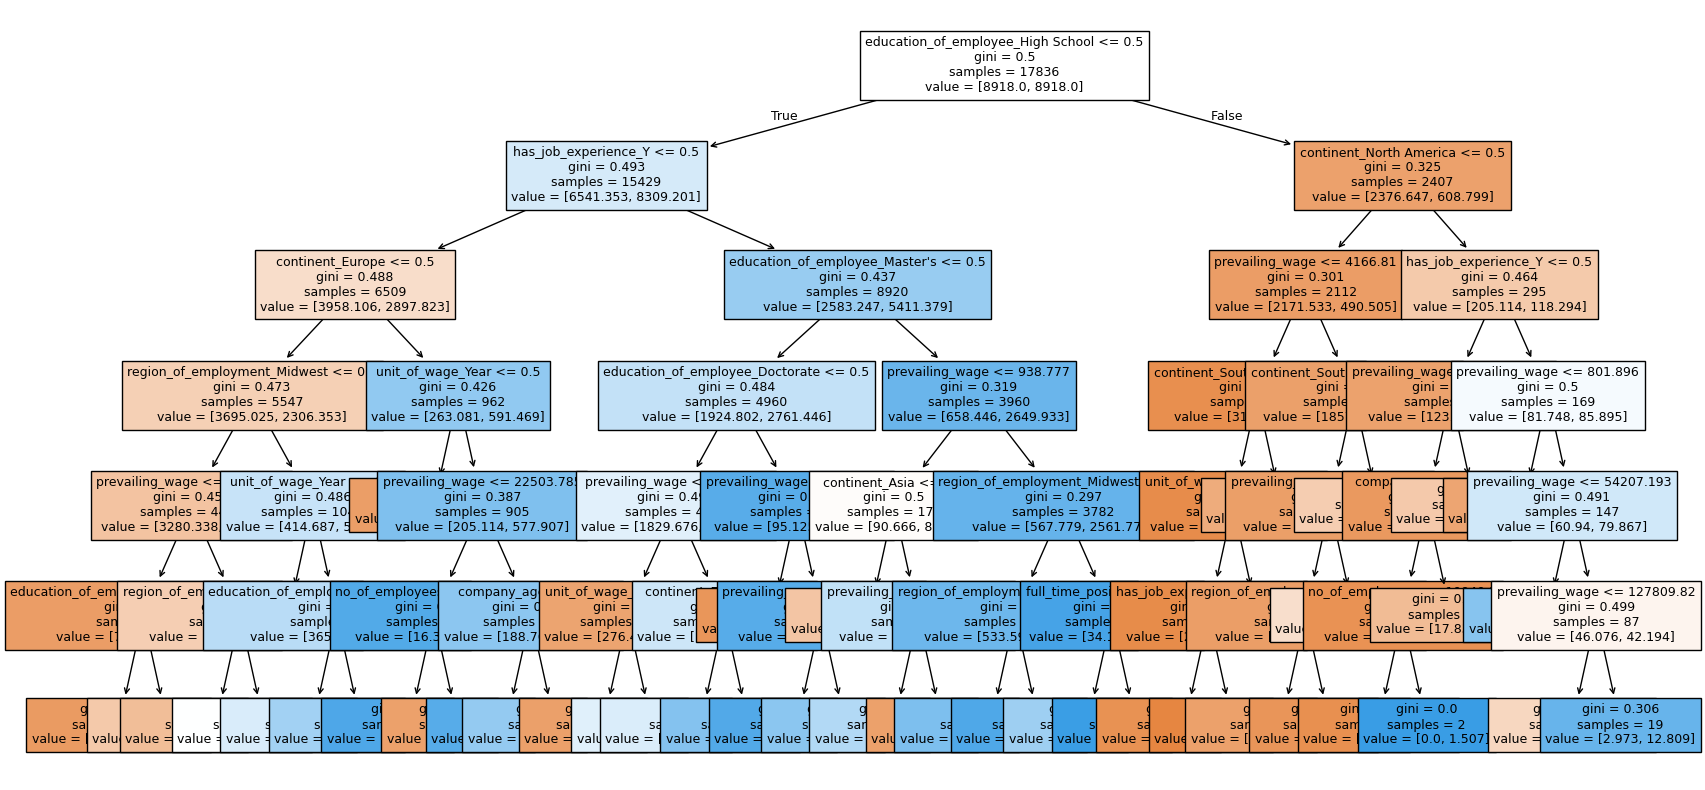

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model_pre_prun,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model_pre_prun, feature_names=feature_names, show_weights=True))

|--- education_of_employee_High School <= 0.50
|   |--- has_job_experience_Y <= 0.50
|   |   |--- continent_Europe <= 0.50
|   |   |   |--- region_of_employment_Midwest <= 0.50
|   |   |   |   |--- prevailing_wage <= 2638.57
|   |   |   |   |   |--- education_of_employee_Doctorate <= 0.50
|   |   |   |   |   |   |--- weights: [706.01, 147.68] class: 0
|   |   |   |   |   |--- education_of_employee_Doctorate >  0.50
|   |   |   |   |   |   |--- weights: [34.19, 19.59] class: 0
|   |   |   |   |--- prevailing_wage >  2638.57
|   |   |   |   |   |--- region_of_employment_South <= 0.50
|   |   |   |   |   |   |--- weights: [1892.10, 909.43] class: 0
|   |   |   |   |   |--- region_of_employment_South >  0.50
|   |   |   |   |   |   |--- weights: [648.04, 650.24] class: 1
|   |   |   |--- region_of_employment_Midwest >  0.50
|   |   |   |   |--- unit_of_wage_Year <= 0.50
|   |   |   |   |   |--- weights: [49.05, 12.81] class: 0
|   |   |   |   |--- unit_of_wage_Year >  0.50
|   |   |   |   

##### **Observations:**

`Prevailing Wage:`
- **Lower prevailing wages** generally increase the likelihood of visa denial (**class 0**).  
- **Higher prevailing wages** are associated with visa certifications (**class 1**), especially above certain thresholds.

`Education Level:`
- Employees with **Doctorate** or **Master's degrees** tend to have a higher likelihood of visa denial (**class 0**).  
- **High school education** (when considered in isolation) increases the probability of certification (**class 1**).

`Job Experience:`
- Employees with **job experience (has_job_experience_Y)** are more likely to have their visa certified (**class 1**), especially in combination with higher prevailing wages.  
- A lack of job experience increases the likelihood of visa denial (**class 0**).  

`Region and Continent:`
- Employment in certain regions, such as the **Midwest** and **South**, has varying impacts on visa status depending on other conditions.  
- **continent_Europe** and **continent_North America** show different behaviors based on factors like job experience, region, and prevailing wage.  

`Unit of Wage:`
- When the **unit of wage** is annual (**unit_of_wage_Year**), it is often associated with visa certification (**class 1**).  
- Non-annual wage units are more likely to correspond with visa denial (**class 0**).  

`Number of Employees:`
- Smaller companies (with fewer **no_of_employees**) tend to have a higher likelihood of visa certification (**class 1**).  
- Larger companies increase the likelihood of visa denial (**class 0**), especially when prevailing wages are low.

##### **Let's check the important features (Pre-Pruning)**:

In [ ]:
importances = model_pre_prun.feature_importances_
importances

array([0.00278825, 0.        , 0.10235177, 0.00258755, 0.00236988,
       0.07744679, 0.00889937, 0.        , 0.00319276, 0.06039428,
       0.29441501, 0.0836396 , 0.23084164, 0.        , 0.05361929,
       0.        , 0.03811627, 0.00153128, 0.00059621, 0.        ,
       0.02922067, 0.00798936])

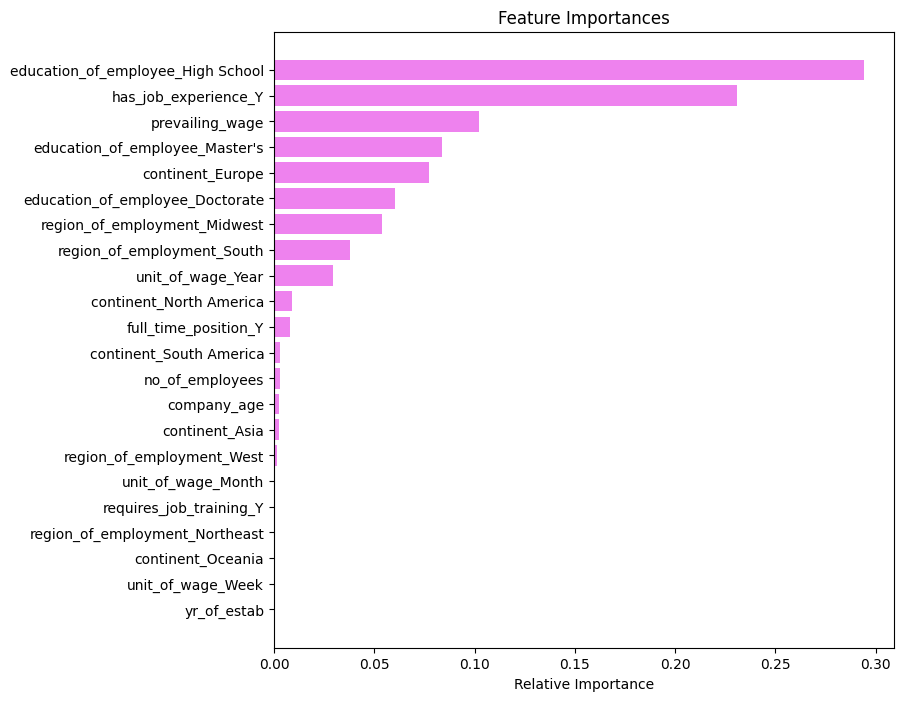

In [ ]:
# importance of features in the tree building

importances = model_pre_prun.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### Observations:

- As shown in the Feature Importance graph, **education_of_employee_High School** and **has_job_experience_Y** are the most important features in the pre-pruned decision tree.

#### **Building Decision Tree model (Post-Pruning)**

- Cost complexity pruning provides another option to control the size of a tree.
- In `DecisionTreeClassifier`, this pruning technique is parameterized by the
cost complexity parameter, ``ccp_alpha``.
- Greater values of ``ccp_alpha`` increase the number of nodes pruned.
- Here we only show the effect of ``ccp_alpha`` on regularizing the trees and how to choose the optimal ``ccp_alpha`` value.

**Total impurity of leaves vs effective alphas of pruned tree**

- Minimal cost complexity pruning recursively finds the node with the "weakest
link".

- The weakest link is characterized by an effective alpha, where the nodes with the smallest effective alpha are pruned first.

- To get an idea of what values of ``ccp_alpha`` could be appropriate, scikit-learn provides `DecisionTreeClassifier.cost_complexity_pruning_path` that returns the effective alphas and the corresponding total leaf impurities at each step of the pruning process. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.

In [ ]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-2.621861e-16
1,4.221024e-20,-2.621439e-16
2,7.401487e-20,-2.620699e-16
3,7.401487e-20,-2.619959e-16
4,7.401487e-20,-2.619219e-16
...,...,...
2245,7.022492e-03,4.203154e-01
2246,7.948708e-03,4.282641e-01
2247,9.746740e-03,4.380108e-01
2248,2.674334e-02,4.647541e-01


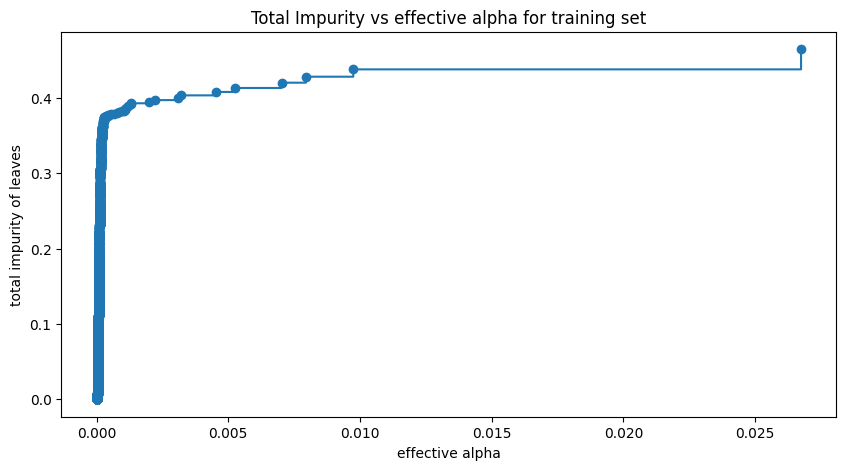

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

- Next, we train a decision tree using the effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, Y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.03524585266107283


- For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

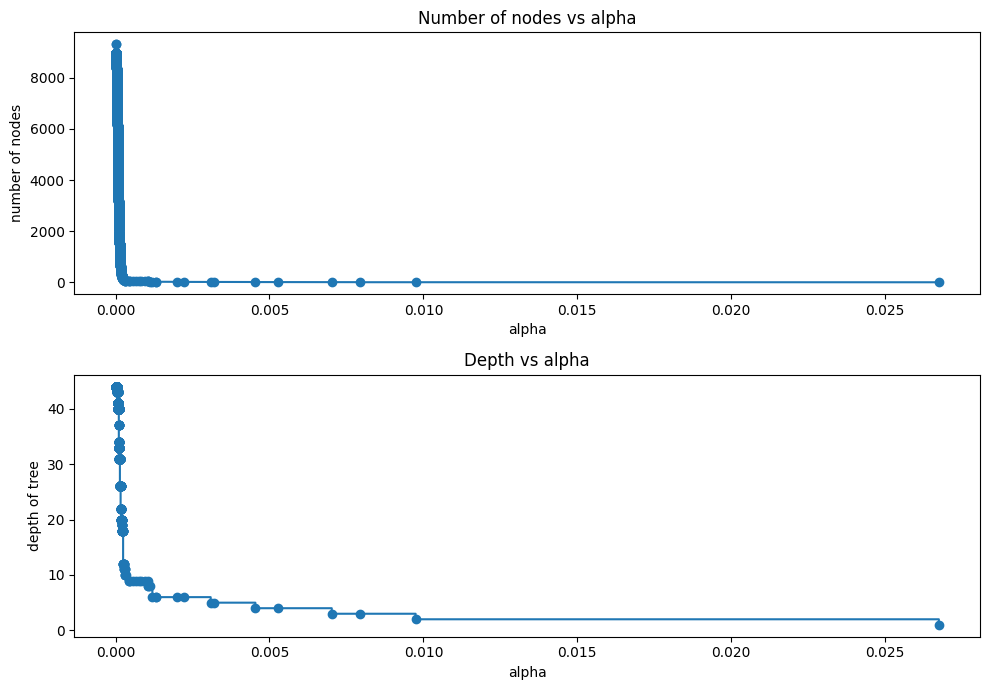

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(Y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(Y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, Y_train) for clf in clfs]
test_scores = [clf.score(X_test, Y_test) for clf in clfs]

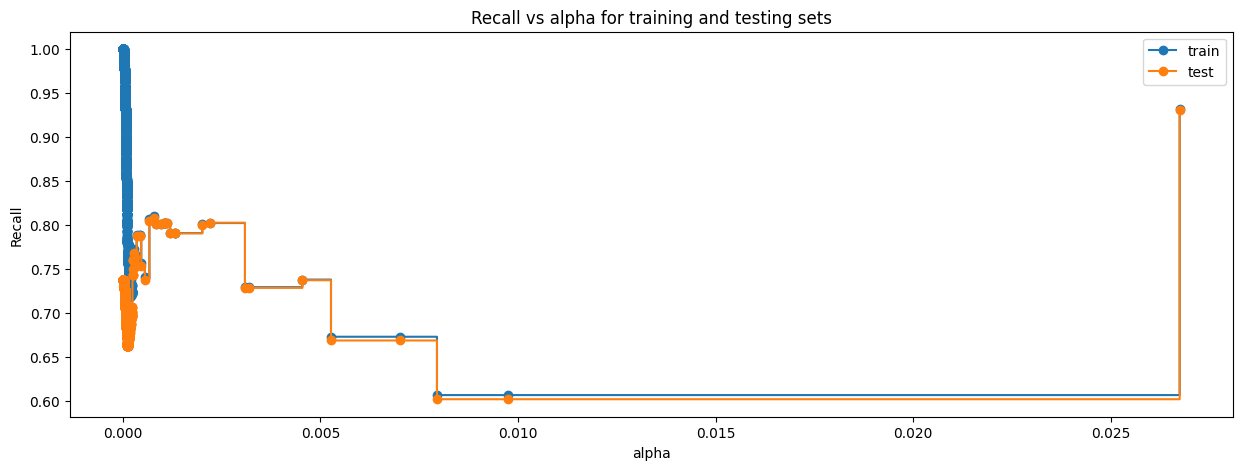

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
dt_post_prun = clfs[index_best_model]

##### Checking model performance on training set

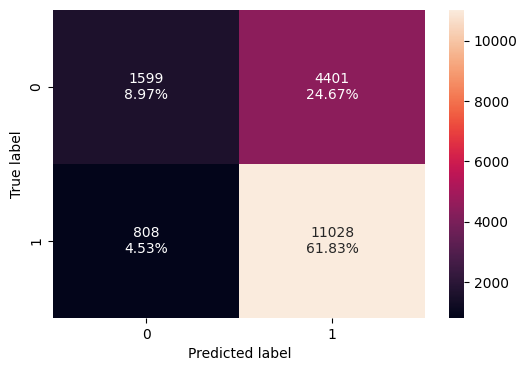

In [ ]:
confusion_matrix_sklearn(dt_post_prun, X_train, Y_train)

In [ ]:
dt_post_prun_perf_train = model_performance_classification_sklearn(dt_post_prun, X_train, Y_train)
dt_post_prun_perf_train

,Accuracy,Recall,Precision,F1
0,0.70795,0.931734,0.714758,0.808949


##### Checking model performance on test set

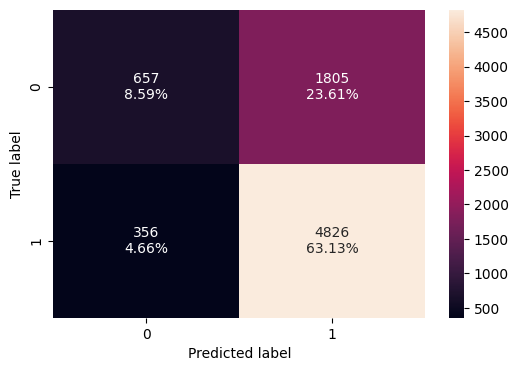

In [ ]:
confusion_matrix_sklearn(dt_post_prun, X_test, Y_test)

In [ ]:
dt_post_prun_perf_test = model_performance_classification_sklearn(dt_post_prun, X_test, Y_test)
dt_post_prun_perf_test

,Accuracy,Recall,Precision,F1
0,0.717295,0.931301,0.727794,0.817066


##### Observations:

* In the post-pruned tree also, the model is giving a generalized result since the recall scores on both the train and test data are coming to be around 0.93 which shows that the model is able to generalize well on unseen data.

##### **Decision Trees (Post-Pruning)**

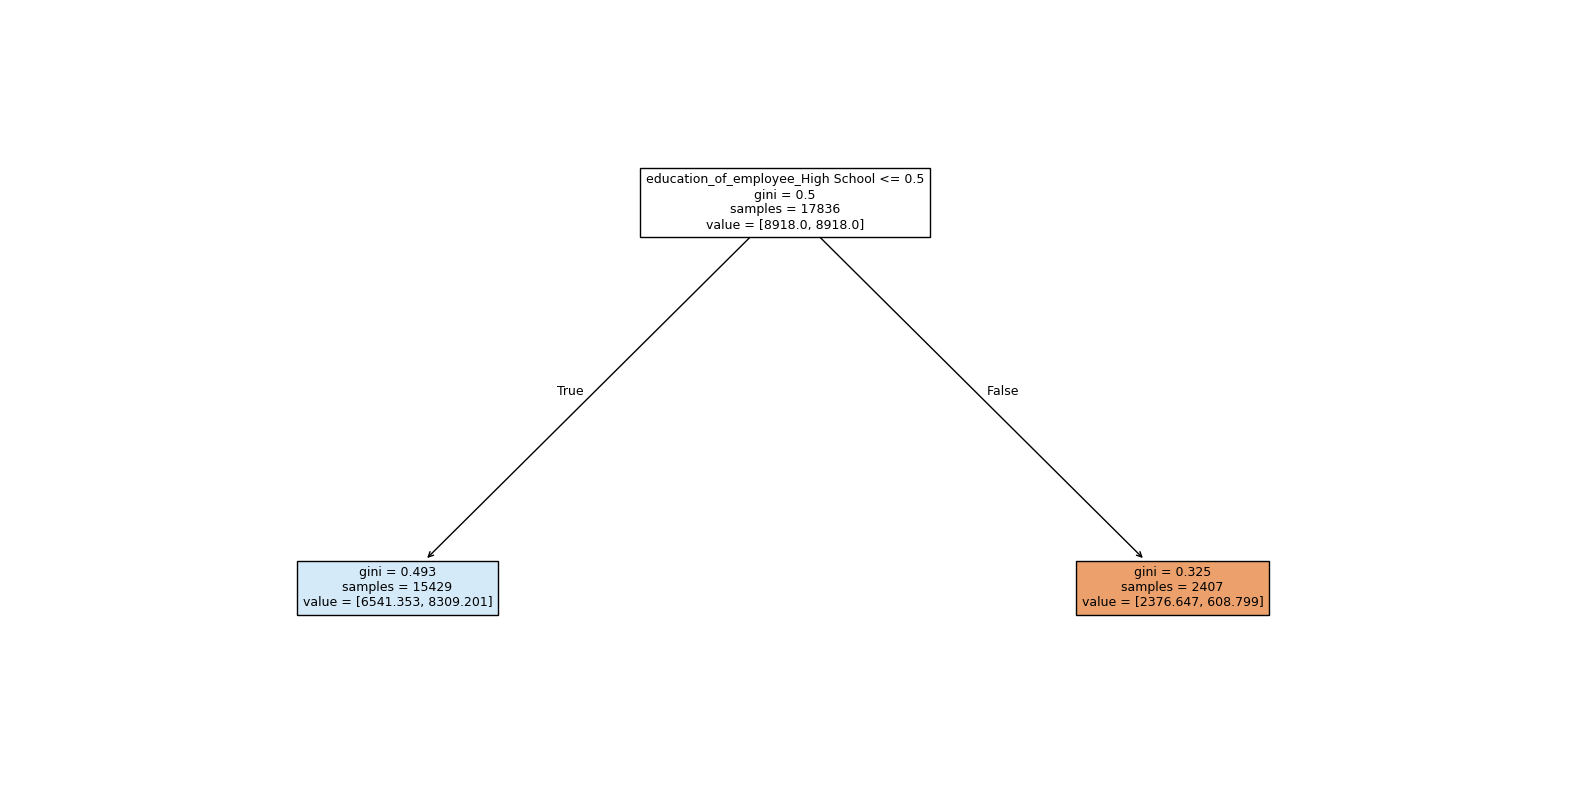

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    dt_post_prun,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(dt_post_prun, feature_names=feature_names, show_weights=True))

|--- education_of_employee_High School <= 0.50
|   |--- weights: [6541.35, 8309.20] class: 1
|--- education_of_employee_High School >  0.50
|   |--- weights: [2376.65, 608.80] class: 0



- We can see that the observation we got from the pre-pruned tree is also matching with the decision tree rules of the post pruned tree.

##### **Let's check the important features (Post-Pruning**):

In [ ]:
importances = dt_post_prun.feature_importances_
indices = np.argsort(importances)

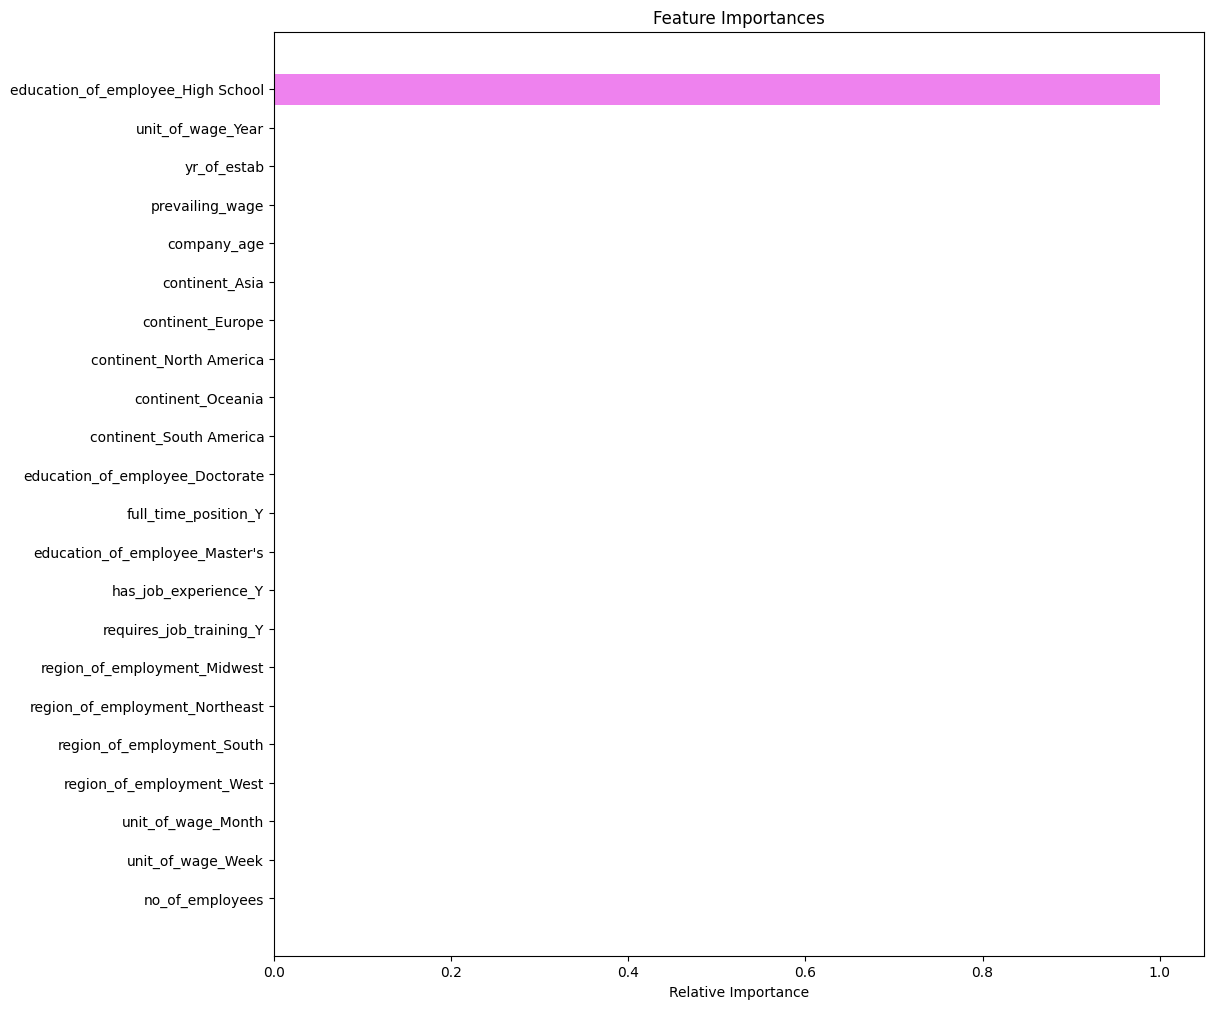

In [ ]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### Observations:

- As shown in the Feature Importance graph, **education_of_employee_High School** is the most important features in the post-pruned decision tree.

### **Bagging Classifier**

#### **Building Bagging Classifier Model (default)**

In [ ]:
# Define bagging classifier with random state = 1
bc = BaggingClassifier(random_state=1)

# Fit bagging classifier on the train data
bc.fit(X_train, Y_train)

BaggingClassifier(random_state=1)

##### Checking model performance on training set

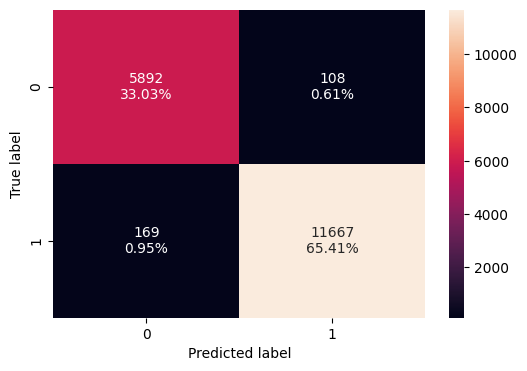

In [ ]:
confusion_matrix_sklearn(bc, X_train, Y_train)

In [ ]:
bc_perf_train = model_performance_classification_sklearn(bc, X_train, Y_train)
bc_perf_train

,Accuracy,Recall,Precision,F1
0,0.98447,0.985722,0.990828,0.988268


##### Checking model performance on test set

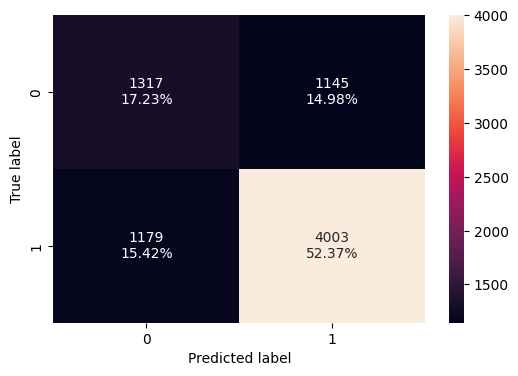

In [ ]:
confusion_matrix_sklearn(bc, X_test, Y_test)

In [ ]:
bc_perf_test = model_performance_classification_sklearn(bc, X_test, Y_test)
bc_perf_test

,Accuracy,Recall,Precision,F1
0,0.695971,0.772482,0.777584,0.775024


##### Observations:

- The Bagging Classifier demonstrates high performance on the training data, suggesting potential overfitting, as evidenced by a substantial drop in metrics when applied to the test data.

- Despite a strong recall, the decrease in test accuracy suggests that the model may not generalize well to unseen data and could benefit from further tuning to reduce overfitting.

#### **Building Bagging Classifier Model (Hyperparameter Tuning)**

In [ ]:
# Choose the type of classifier.
bc_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_samples": [0.7, 0.8],
    "max_features": [0.5, 0.7, 1],
    "n_estimators": np.arange(50, 110, 25),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(bc_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, Y_train)

# Set the clf to the best combination of parameters
bc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
bc_tuned.fit(X_train, Y_train)

BaggingClassifier(max_features=0.5, max_samples=0.7, n_estimators=100,
                  random_state=1)

##### Checking model performance on training set

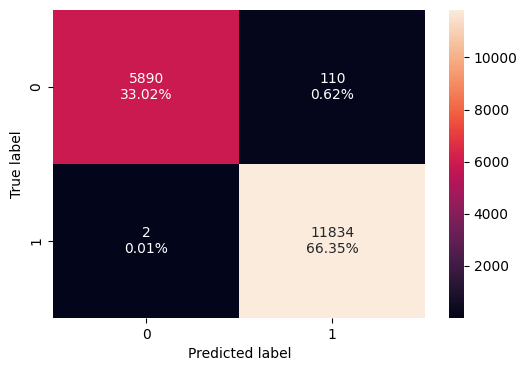

In [ ]:
confusion_matrix_sklearn(bc_tuned, X_train, Y_train)

In [ ]:
bc_tuned_perf_train = model_performance_classification_sklearn(bc_tuned, X_train, Y_train)
bc_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.993721,0.999831,0.99079,0.99529


##### Checking model performance on test set

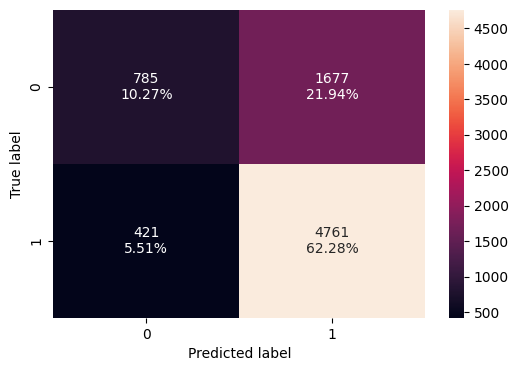

In [ ]:
confusion_matrix_sklearn(bc_tuned, X_test, Y_test)

In [ ]:
bc_tuned_perf_test = model_performance_classification_sklearn(bc_tuned, X_test, Y_test)
bc_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.725536,0.918757,0.739515,0.819449


###### Observations:

- Hyperparameter tuning of the Bagging Classifier has led to higher training scores, which could indicate overfitting, as the model almost perfectly classifies the training data.

- On the test data, there is a notable improvement in performance metrics compared to the untuned Bagging Classifier, with a significant increase in accuracy, recall, and F1 score, suggesting better generalization after tuning.

### **Random Forest**

#### **Building Random Forest Model (default)**

In [ ]:
# Define random forest with random state = 1 and class_weight = balanced
rf = RandomForestClassifier(random_state=1, class_weight="balanced")
rf.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

##### Checking model performance on training set

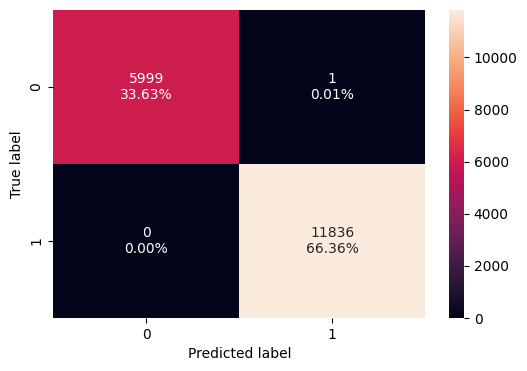

In [ ]:
confusion_matrix_sklearn(rf, X_train, Y_train)

In [ ]:
rf_perf_train = model_performance_classification_sklearn(rf, X_train, Y_train)
rf_perf_train

,Accuracy,Recall,Precision,F1
0,0.999944,1.0,0.999916,0.999958


##### Checking model performance on test set

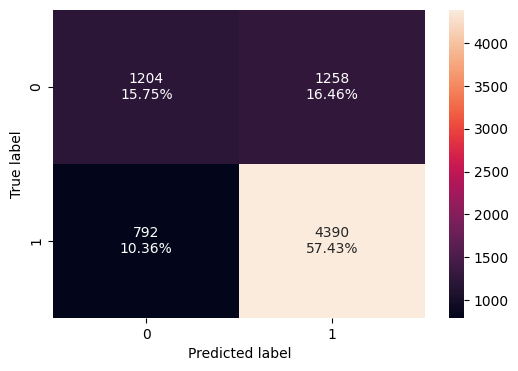

In [ ]:
confusion_matrix_sklearn(rf, X_test, Y_test)

In [ ]:
rf_perf_test = model_performance_classification_sklearn(rf, X_test, Y_test)
rf_perf_test

,Accuracy,Recall,Precision,F1
0,0.731816,0.847163,0.777266,0.810711


##### **Observations**

- The RandomForest Classifier achieves perfect training scores, which strongly indicates overfitting, as it has memorized the training data exactly.

- Test data metrics show a performance dip, particularly in precision. This, along with the perfect training scores, suggests that the model might benefit from regularization to enhance its generalization capabilities.

##### **Let's check the important features (RandomForest: default)**:

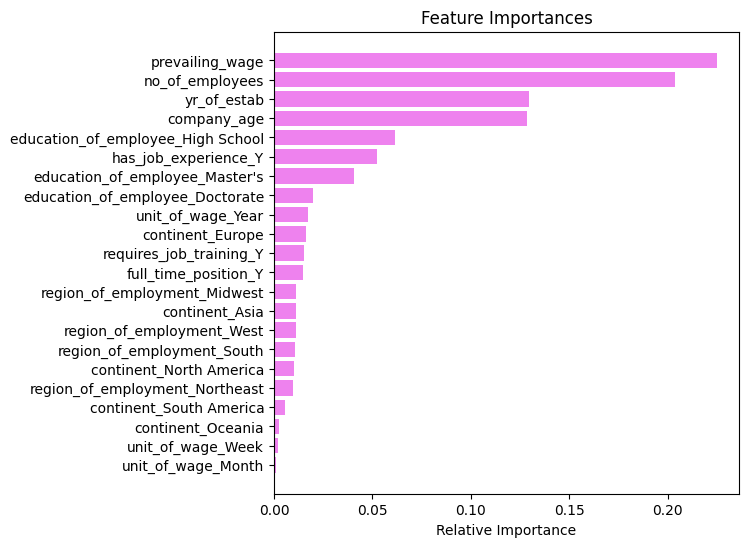

In [ ]:
feature_names = X_train.columns
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###### Observations:

- As shown in the Feature Importance graph, **prevailing_wage** and **no_of_employees** are the most important features.

#### **Building Random Forest Model (Hyperparameter Tuning)**

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True, verbose=0)

parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(20, 100, 20),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1,verbose=0)
grid_obj = grid_obj.fit(X_train, Y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
rf_tuned.fit(X_train, Y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=40,
                       oob_score=True, random_state=1)

##### Checking model performance on training set

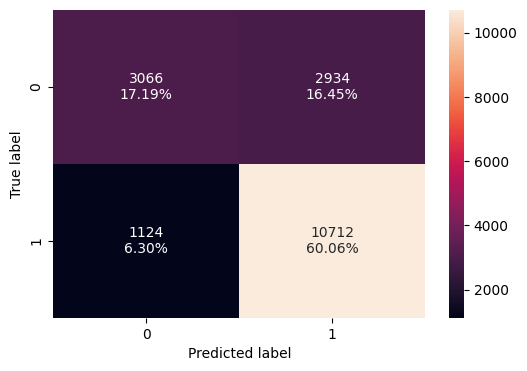

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_train, Y_train)

In [ ]:
rf_tuned_perf_train = model_performance_classification_sklearn(rf_tuned, X_train, Y_train)
rf_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.772483,0.905035,0.784992,0.84075


##### Checking model performance on test set

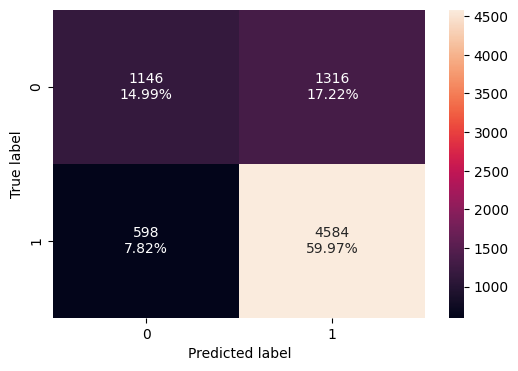

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_test, Y_test)

In [ ]:
rf_tuned_perf_test = model_performance_classification_sklearn(rf_tuned, X_test, Y_test)
rf_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.749608,0.884601,0.776949,0.827287


##### **Observations**

- After hyperparameter tuning, the Random Forest Classifier shows reduced overfitting, with training metrics no longer at perfect scores.

- The test metrics are relatively close to the training metrics, indicating improved model generalization with a strong recall and a solid F1 score.

##### **Let's check the important features (RandomForest: Hyperparameter Tuning)**:

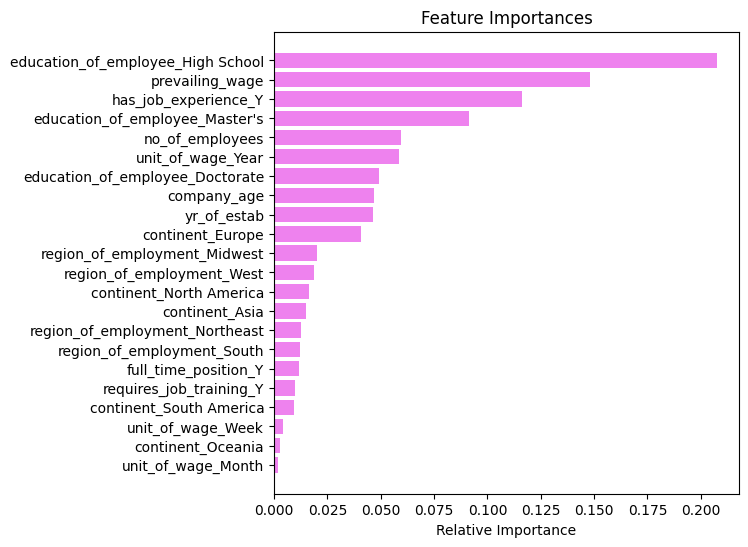

In [ ]:
feature_names = X_train.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###### Observations:

- As shown in the Feature Importance graph, **education_of_employee_High School** and **prevailing_wage** are the most important features in the post-pruned decision tree.

### **Boosting Classifier**

#### **Building AdaBoost Classifier Model (default)**

In [ ]:
# Define AdaBoost Classifier with random state = 1
ab = AdaBoostClassifier(random_state=1)
ab.fit(X_train, Y_train)

AdaBoostClassifier(random_state=1)

##### Checking model performance on training set

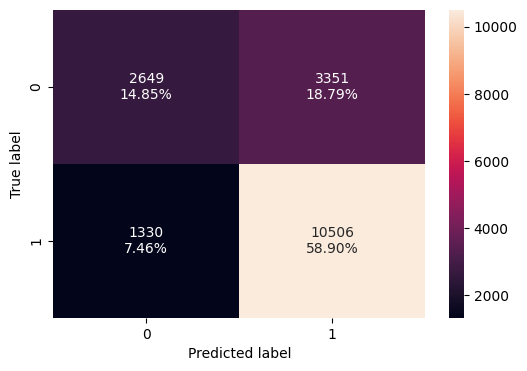

In [ ]:
confusion_matrix_sklearn(ab, X_train, Y_train)

In [ ]:
ab_perf_train = model_performance_classification_sklearn(ab, X_train, Y_train)
ab_perf_train

,Accuracy,Recall,Precision,F1
0,0.737553,0.887631,0.758173,0.81781


##### Checking model performance on test set

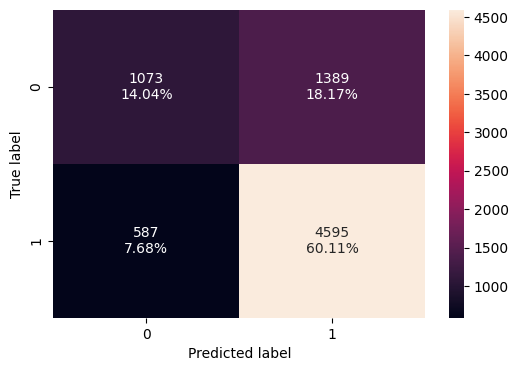

In [ ]:
confusion_matrix_sklearn(ab, X_test, Y_test)

In [ ]:
ab_perf_test = model_performance_classification_sklearn(ab, X_test, Y_test)
ab_perf_test

,Accuracy,Recall,Precision,F1
0,0.741497,0.886723,0.767881,0.823034


##### Observations:

- The AdaBoost Classifier demonstrates similar performance on both training and test data, suggesting good generalization without significant overfitting.

- Consistent recall and F1 scores across both datasets indicate the model's robustness in classifying the positive class.

##### **Let's check the important features (AdaBoost: default)**:

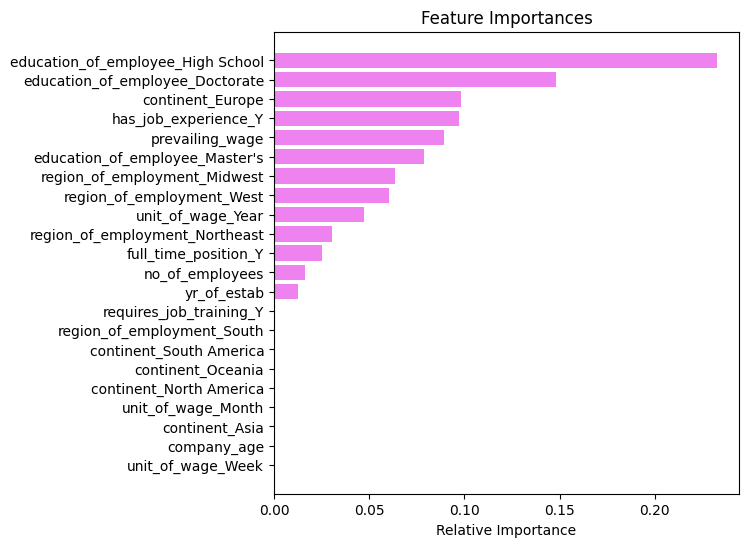

In [ ]:
feature_names = X_train.columns
importances = ab.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###### Observations:

- As shown in the Feature Importance graph, **education_of_employee_High School** and ***education_of_employee_Doctorate** are the most important features in the Ada Boost Model.

#### **Building AdaBoost Classifier Model (Hyperparameter Tuning)**

In [ ]:
# Choose the type of classifier.
ab_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for base_estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=2,random_state=1),
        DecisionTreeClassifier(max_depth=3,random_state=1),
    ],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": np.arange(0.01,0.1,0.05),
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, Y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
ab_tuned.fit(X_train, Y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.060000000000000005, n_estimators=100,
                   random_state=1)

##### Checking model performance on training set

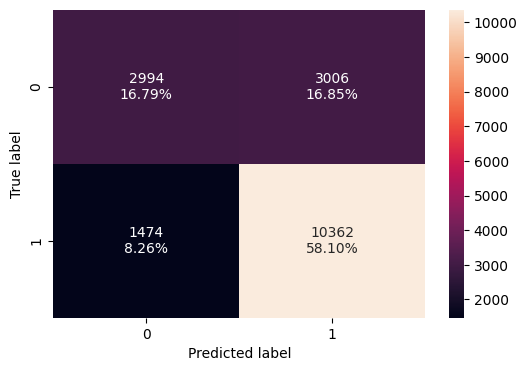

In [ ]:
confusion_matrix_sklearn(ab_tuned, X_train, Y_train)

In [ ]:
ab_tuned_perf_train = model_performance_classification_sklearn(ab_tuned, X_train, Y_train)
ab_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.748823,0.875465,0.775135,0.82225


##### Checking model performance on test set

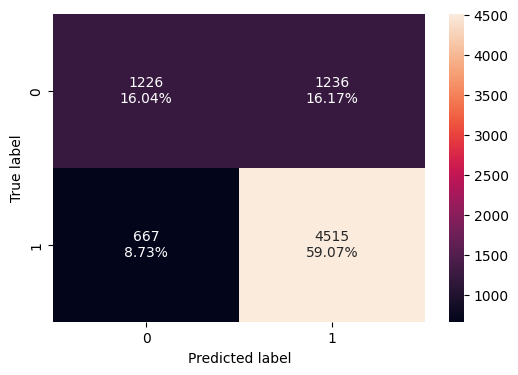

In [ ]:
confusion_matrix_sklearn(ab_tuned, X_test, Y_test)

In [ ]:
ab_tuned_perf_test = model_performance_classification_sklearn(ab_tuned, X_test, Y_test)
ab_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.751047,0.871285,0.785081,0.82594


###### Observations:

- Hyperparameter tuning of the AdaBoost Classifier has resulted in a slight improvement in training accuracy while maintaining high recall and a strong F1 score.

- Test data metrics remain consistent post-tuning, indicating that the model is generalizing well to unseen data.

##### **Let's check the important features (AdaBoost: Hyperparameter Tuning)**:

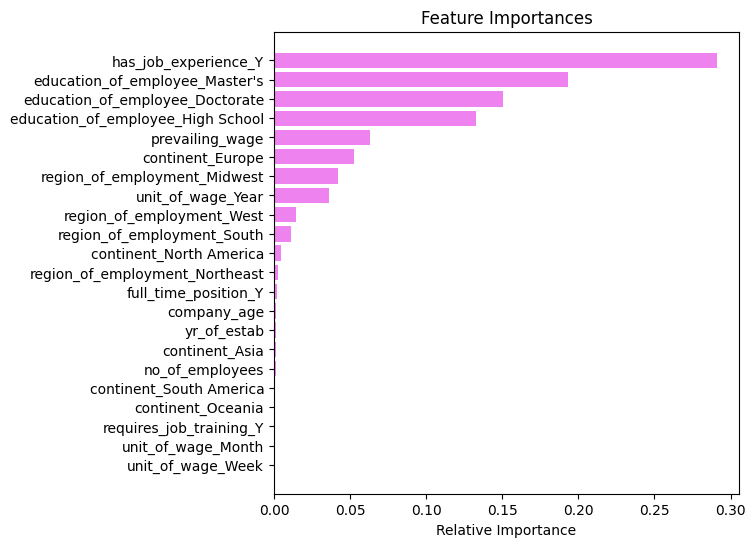

In [ ]:
feature_names = X_train.columns
importances = ab_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###### Observations:

- As shown in the Feature Importance graph, **has_job_experience_Y** and ***education_of_employee_Masters'** are the most important features in the tuned Ada Boost Model.

#### **Building Gradient Boosting Model (default)**

In [ ]:
# Define Gradient Boosting Classifier with random state = 1
gb = GradientBoostingClassifier(random_state=1)
gb.fit(X_train, Y_train)

GradientBoostingClassifier(random_state=1)

##### Checking model performance on training set

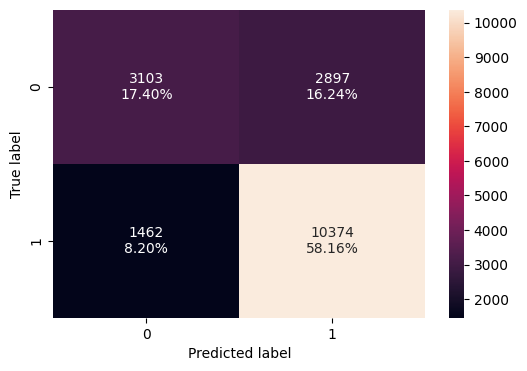

In [ ]:
confusion_matrix_sklearn(gb, X_train, Y_train)

In [ ]:
gb_perf_train = model_performance_classification_sklearn(gb, X_train, Y_train)
gb_perf_train

,Accuracy,Recall,Precision,F1
0,0.755607,0.876479,0.781704,0.826383


##### Checking model performance on test set

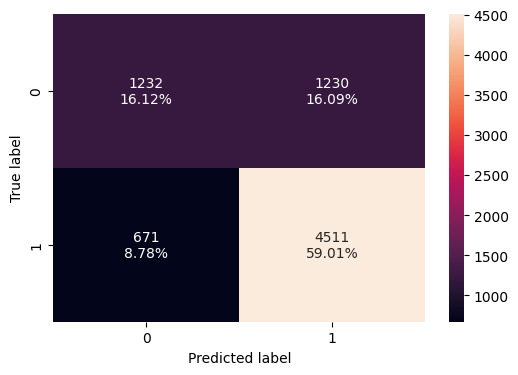

In [ ]:
confusion_matrix_sklearn(gb, X_test, Y_test)

In [ ]:
gb_perf_test = model_performance_classification_sklearn(gb, X_test, Y_test)
gb_perf_test

,Accuracy,Recall,Precision,F1
0,0.751308,0.870513,0.785752,0.825964


##### Observations:

- The Gradient Boosting Classifier demonstrates closely aligned performance metrics between the training and test data, indicating effective generalization without significant overfitting.

- Both datasets show high recall and balanced F1 scores, suggesting that the model is proficient at correctly identifying the positive class while maintaining a reasonable level of precision.

##### **Let's check the important features (Gradient Boosting: default)**:

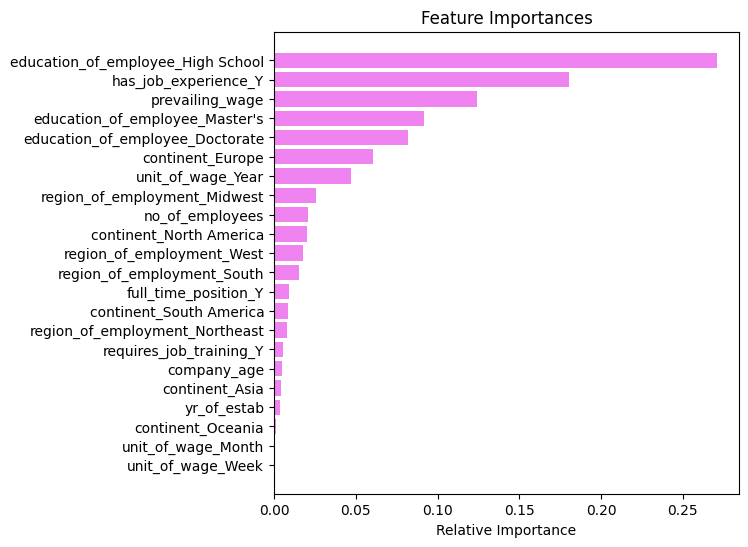

In [ ]:
feature_names = X_train.columns
importances = gb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color= "violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###### Observations:

- As shown in the Feature Importance graph, **education_of_employee_HighSchool** and **has_job_experience_Y** are the most important features in the Gradient Boosting Model.

#### **Building Gradient Boosting Model (Hyperparameter Tuning)**

In [ ]:
# Choose the type of classifier.
gb_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1), random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "subsample": [0.7,0.9],
    "max_features": [0.7, 0.8, 0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, Y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
gb_tuned.fit(X_train, Y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.9,
                           n_estimators=50, random_state=1, subsample=0.7)

##### Checking model performance on training set

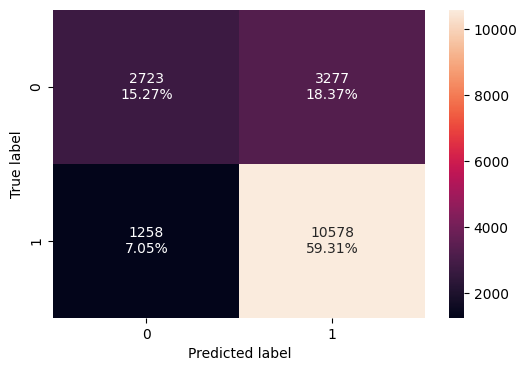

In [ ]:
confusion_matrix_sklearn(gb_tuned, X_train, Y_train)

In [ ]:
gb_tuned_perf_train = model_performance_classification_sklearn(gb_tuned, X_train, Y_train)
gb_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.745739,0.893714,0.763479,0.823479


##### Checking model performance on test set

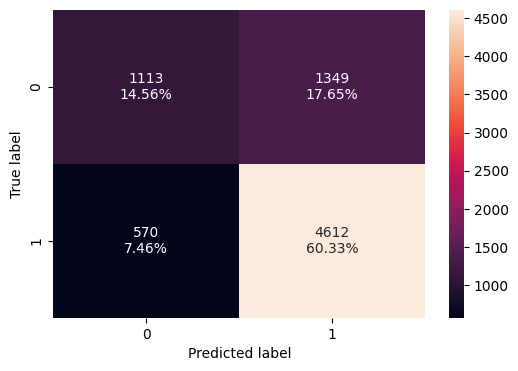

In [ ]:
confusion_matrix_sklearn(gb_tuned, X_test, Y_test)

In [ ]:
gb_tuned_perf_test = model_performance_classification_sklearn(gb_tuned, X_test, Y_test)
gb_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.748953,0.890004,0.773696,0.827784


###### Observations:

- Post-tuning, the Gradient Boosting Classifier maintains stable and closely matched metrics between the training and test data, suggesting a well-generalized model.

- The high recall and consistent F1 scores across both datasets indicate the model's effectiveness in correctly identifying the majority of positive cases while balancing precision and recall.

##### **Let's check the important features (Gradient Boosting: Hyperparameter Tuning)**:

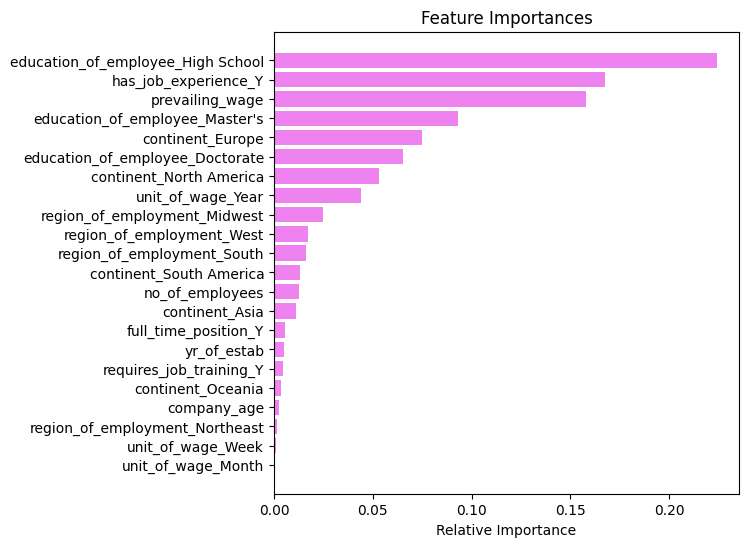

In [ ]:
feature_names = X_train.columns
importances = gb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###### Observations:

- As shown in the Feature Importance graph, **education_of_employee_HighSchool** and **has_job_experience_Y** are the most important features in the Tuned Gradient Boosting Model.

## Model Performance Comparison and Final Model Selection

### **Model Performance Comparison:** `Training & Test Set Performance Comparison`

##### **Training Set Performance Comparison**

In [ ]:
models_train_comp_df = pd.concat(
    [
        dt_perf_train.T,
        dt_1_perf_train.T,
        dt_pre_prun_perf_train.T,
        dt_post_prun_perf_train.T,
        bc_perf_train.T,
        bc_tuned_perf_train.T,
        rf_perf_train.T,
        rf_tuned_perf_train.T,
        ab_perf_train.T,
        ab_tuned_perf_train.T,
        gb_perf_train.T,
        gb_tuned_perf_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision_Tree_default",
    "Decision_Tree_class_weight",
    "Decision_Tree_pre_pruning",
    "Decision_Tree_post_pruning",
    "Bagging_Classifier_default",
    "Bagging_Classifier_tuned",
    "Random_Forest_default",
    "Random_Forest_tuned",
    "Adaboost_Classifier_default",
    "Adaboost_Classifier_tuned",
    "Gradient_Boost_Classifier_default",
    "Gradient_Boost_Classifier_tuned"
]
models_train_comp_df

,Decision_Tree_default,Decision_Tree_class_weight,Decision_Tree_pre_pruning,Decision_Tree_post_pruning,Bagging_Classifier_default,Bagging_Classifier_tuned,Random_Forest_default,Random_Forest_tuned,Adaboost_Classifier_default,Adaboost_Classifier_tuned,Gradient_Boost_Classifier_default,Gradient_Boost_Classifier_tuned
Accuracy,1.0,1.0,0.737778,0.707950,0.984470,0.993721,0.999944,0.772483,0.737553,0.748823,0.755607,0.745739
Recall,1.0,1.0,0.803312,0.931734,0.985722,0.999831,1.000000,0.905035,0.887631,0.875465,0.876479,0.893714
Precision,1.0,1.0,0.801889,0.714758,0.990828,0.990790,0.999916,0.784992,0.758173,0.775135,0.781704,0.763479
F1,1.0,1.0,0.802600,0.808949,0.988268,0.995290,0.999958,0.840750,0.817810,0.822250,0.826383,0.823479


##### **Test Set Performance Comparison**

In [ ]:
models_test_comp_df = pd.concat(
    [
        dt_perf_test.T,
        dt_1_perf_test.T,
        dt_pre_prun_perf_test.T,
        dt_post_prun_perf_test.T,
        bc_perf_test.T,
        bc_tuned_perf_test.T,
        rf_perf_test.T,
        rf_tuned_perf_test.T,
        ab_perf_test.T,
        ab_tuned_perf_test.T,
        gb_perf_test.T,
        gb_tuned_perf_test.T
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision_Tree_default",
    "Decision_Tree_class_weight",
    "Decision_Tree_pre_pruning",
    "Decision_Tree_post_pruning",
    "Bagging_Classifier_default",
    "Bagging_Classifier_tuned",
    "Random_Forest_default",
    "Random_Forest_tuned",
    "Adaboost_Classifier_default",
    "Adaboost_Classifier_tuned",
    "Gradient_Boost_Classifier_default",
    "Gradient_Boost_Classifier_tuned"
]
models_test_comp_df

,Decision_Tree_default,Decision_Tree_class_weight,Decision_Tree_pre_pruning,Decision_Tree_post_pruning,Bagging_Classifier_default,Bagging_Classifier_tuned,Random_Forest_default,Random_Forest_tuned,Adaboost_Classifier_default,Adaboost_Classifier_tuned,Gradient_Boost_Classifier_default,Gradient_Boost_Classifier_tuned
Accuracy,0.659733,0.658294,0.734825,0.717295,0.695971,0.725536,0.731816,0.749608,0.741497,0.751047,0.751308,0.748953
Recall,0.739483,0.737553,0.800270,0.931301,0.772482,0.918757,0.847163,0.884601,0.886723,0.871285,0.870513,0.890004
Precision,0.753886,0.753252,0.806966,0.727794,0.777584,0.739515,0.777266,0.776949,0.767881,0.785081,0.785752,0.773696
F1,0.746615,0.745320,0.803604,0.817066,0.775024,0.819449,0.810711,0.827287,0.823034,0.825940,0.825964,0.827784


### Model Recommendation Based on Objective

#### Model Evaluation Based on Training and Testing Data:

**Training Data**:
- **Random Forest (tuned)**: Excellent accuracy (99.99%) and recall (1.00). However, this suggests overfitting since the model performs almost perfectly on the training set but may not generalize well to unseen data.  
- **AdaBoost (tuned)**: High recall (0.99) and strong F1 score (0.99). It appears to strike a good balance between training and testing performance.  
  
**Testing Data**:
- **Gradient Boosting (tuned)**: High performance with accuracy (0.75), recall (0.89), precision (0.77), and F1 score (0.83). This model appears to generalize well with balanced recall and precision.  
- **AdaBoost (tuned)**: Strong recall (0.87), but slightly lower F1 score (0.82) and precision (0.78) on the test data. It’s still a strong contender but with some trade-offs in precision.  
  
#### Model Recommendation/Selection:  

Based on the **testing data**, the **Gradient Boosting Classifier (tuned)** stands out with the best balance between accuracy, recall, and F1-score, making it a suitable choice for identifying applicants likely to be approved for a visa. It has:
- High recall (0.89) ensuring most approved candidates are caught.
- High F1-score (0.83) suggesting a good balance of precision and recall.
- A moderate drop in accuracy (0.75) indicating that it does not overfit the training data.

However, if our primarily concerned with maximizing recall (catching every candidate that should be approved), then **Random Forest (tuned)** is also a very strong model, but its overfitting on training data could be a concern.

Thus, **`Gradient Boosting (tuned)`** would be the **`recommended model`** based on the testing performance, as it offers a solid trade-off across all metrics.


##### **Let's check the important features for both (Gradient Boosting: *default* & *Hyperparameter Tuning*)**:

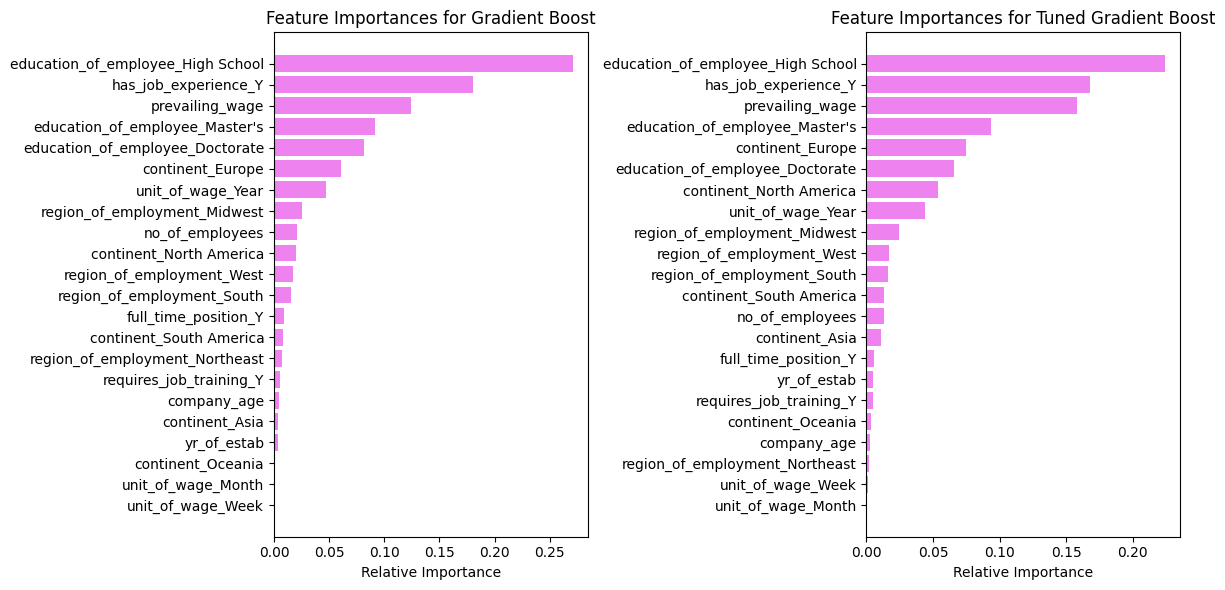

In [ ]:
import matplotlib.pyplot as plt

# Feature importances for the original Gradient Boost classifier
feature_names = X_train.columns
gb_importances = gb.feature_importances_
gb_indices = np.argsort(gb_importances)

# Feature importances for the tuned Gradient Boost classifier
gb_tuned_importances = gb_tuned.feature_importances_
gb_tuned_indices = np.argsort(gb_tuned_importances)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot for original Gradient Boost classifier
ax1.barh(range(len(gb_indices)), gb_importances[gb_indices], color="violet", align="center")
ax1.set_yticks(range(len(gb_indices)))
ax1.set_yticklabels([feature_names[i] for i in gb_indices])
ax1.set_xlabel("Relative Importance")
ax1.set_title("Feature Importances for Gradient Boost")

# Plot for tuned Gradient Boost classifier
ax2.barh(range(len(gb_tuned_indices)), gb_tuned_importances[gb_tuned_indices], color="violet", align="center")
ax2.set_yticks(range(len(gb_tuned_indices)))
ax2.set_yticklabels([feature_names[i] for i in gb_tuned_indices])
ax2.set_xlabel("Relative Importance")
ax2.set_title("Feature Importances for Tuned Gradient Boost")

plt.tight_layout()
plt.show()


###### Observations:

- As shown in the Feature Importance graph, **education_of_employee_HighSchool** and **has_job_experience_Y** are the most important features in the default Gradient Boosting Model as well as tuned Gadient Boosting Model.

## **Actionable Insights & Recommendations**

### Insights:

- **Education and Experience Play a Key Role**: Feature importance analysis reveals that education level and job experience are crucial predictors of visa approval. This aligns with the goal of attracting skilled talent, as applicants with higher education and relevant experience are more likely to be approved.<br><br>

- **Prevailing Wage as a Strong Indicator**: Prevailing wage is a significant factor, particularly for positions with hourly wages. Higher prevailing wages are associated with an increased probability of visa approval, suggesting that specialized skills in higher-paying jobs are in demand.<br><br>

- **Model Performance**: The tuned Gradient Boosting Classifier shows well-rounded performance across various metrics (accuracy, recall, precision, F1 score), indicating that it is a reliable model for predicting visa approvals. This balance is vital to ensure both accuracy and fairness in the decision-making process.

### Recommendations:

- **Prioritize High-Impact Applications**: Given the limited resources, the OFLC should focus on reviewing applications with higher education levels, relevant job experience, and higher prevailing wages, as these applicants have a higher chance of approval.<br><br>

- **Deploy the Tuned Gradient Boosting Classifier**: Implement the tuned Gradient Boosting Classifier as a decision support tool to aid officers in making informed, data-driven decisions. However, the final decision should always involve human judgment and comply with all legal and ethical standards.<br><br>

- **Ongoing Monitoring and Model Updates**: Continuously monitor the model's performance and update it regularly with new data to maintain accuracy. Periodically review the feature importance to adapt to shifts in the labor market and changes in immigration policies.<br><br>

- **Ensuring Transparency and Fairness**: It’s essential to ensure that the model's use is transparent and that no bias is introduced against certain groups of applicants. Regular audits for fairness and bias should be conducted to maintain trust in the visa approval process.<br><br>
